# ****MIE 1517 - Intro to Deep Learning****
# **Project - Music Recommendation System**

####**Group 12**

**Group Members: Daniel Roberts, Tiffany Costas, Cameron Smith, Amreen Imrit**

* [**1. Problem Definition & Overview**](#problem-def)
  * [1.1 Literature Review](#lit-review)
  * [1.2 Overview of Datasets Used](#dataset-overview)
  * [1.3 End to End Pipeline of the Model](#pipeline)
* [**2. Load Libraries & Dataset**](#2)
    * [2.1. Load Libraries](#2.1)
    * [2.2. Load Dataset](#2.2)
      * [2.2.1 Extract Spotify Data](#2.2.1)
      * [2.2.2 Extract Song Previews, Lyrics & Metadata](#2.2.2)
      * [2.2.3 Create Global Track & Session List](#2.2.3)
* [**3. Pre-Training Phase**](#pretraining)
    * [3.1 Mel-Spectrogram Embedding Creation](#mel-embed)
        * [3.1.1 Mel-Spectrograms Creation](#3.1.1)
        * [3.1.2 Mel Embedding Training: Learning Audio Features](#3.1.2)
            * [3.1.2.1 Loading & Processing GZAN Functions](#3.1.2.1)
            * [3.1.2.2 Model Architecture, Training & Evaluation Functions](#3.1.2.2)
            * [3.1.2.3 Training Execution & Final Model Selection](#3.1.2.3)
        * [3.1.3 Results Interpretation](#3.1.3)
        * [3.1.4 Extract Audio Embeddings from Mel-Spectrogram](#3.1.4)
    * [3.2 Lyrics Embeddings Creation](#lyric-embed)
    * [3.3 Co-occurrence Embeddings Creation](#cooccurence-embed)
* [**4. Training Phase**](#training-phase)
    * [4.1 Training Setup](#4.1)
        * [4.1.1 Load Track Metadata & Build Last.fm Tag Vocabulary](#4.1.1)
        * [4.1.2 Model Hyperparameters & Configuration](#4.1.2)
        * [4.2.3 Fusion Transformer](#4.2.3)
    * [4.2 Track Encoding Module](#4.2)
        * [4.2.1 Learnable Positional Encoding](#4.2.1)
        * [4.2.2 Modality-Specific Encoders](#4.2.2)
    * [4.3 Full Track and Session Modeling](#4.3)
        * [4.3.1 TrackEncoder: Combining Multi-Modal Information](#4.3.1)
        * [4.3.2 SessionPredictor: Modeling Track Sequences](#4.3.2)
        * [4.3.3 SessionModel: End-to-End Forward Pass](#4.3.3)
    * [4.4 Dataset Classes and Batching](#4.4)
        * [4.4.1 MusicDataset: Per-Track Feature Extraction](#4.4.1)
        * [4.4.1 MusicDataset: Per-Track Feature Extraction](#4.4.2)
        * [4.4.3 SessionDataset: Preparing Sequential Sessions](#4.4.3)
        * [4.4.4 Collate Function: Variable-Length Batch Padding](#4.4.4)
    * [4.5 Training and Evaluation](#4.5)
    * [4.6 End-to-End Training Pipeline](#4.6)
    * [4.7 Interpretation of Results](#4.7)
* [**5. Ablation Study**](#ablation)
* [**6. Conclusion**](#conclusion)
    * [6.1 Challenges & Insights](#challenges-insights)
    * [6.2 Model Limitations](#limitations)
    * [6.3 Next Steps](#next-steps)


---
---

<a name="problem-def"><a>
# **1. Problem  Definition & Overview**

**This project aims to create a music recommendation system utilizing a multi-modal strategy**

**Current Landscape:**

- Streaming platforms like Spotify employ robust algorithms for song recommendations.

- Despite features such as Smart Shuffle and Spotify's DJ, there remains a gap in delivering truly personalized experiences.

**Identified Challenge:**

- Existing recommendations often fail to capture the unique listening nuances and deep contextual relationships of individual users (from our personal experiences).

**Our Goal:**

- Analyze sequential listening behavior (the order of songs listened) and song features (audio characteristics and lyrics) to uncover patterns that enhance personalization.

**Our Approach:**

- Extract audio features from Mel spectrograms using a convolutional neural network (CNN).

- Embed lyrics with a BERT-based model.

- Incorporate song co-occurrence patterns to build a system that reveals acoustic and contextual relationships.

- Use song metadata to further the patterns.

This multi-modal strategy is designed to bridge the personalization gap and offer users more tailored music recommendations.

---

<a name="lit-review"><a>
## **1.1 Literature Review**


**This section reviews previous research on  recommendation systems. The focus ranging from tradtional methods, multi-modal strategies and transformer techniques.**

### **Traditional Music Recommendation**
- **Collaborative Filtering**: Koren et al. (2009) introduced matrix factorization to model user-item interactions (*IEEE Computer*, [DOI: 10.1109/MC.2009.263]).
- **Content-Based Filtering**: Celma (2008) explored audio features and metadata for recommendation (*ACM RecSys*).

### **Deep Learning in Recommendation Systems**
- **Neural Collaborative Filtering**: He et al. (2017) used neural networks for user-item modeling (*WWW '17*, [DOI: 10.1145/3038912.3052569]).
- **Audio-Based Features**: van den Oord et al. (2013) applied CNNs to spectrograms (*NIPS*).

### **Multi-Modal Music Recommendation**
- **Audio and Lyrics**: Tsaptsinos (2017) classified genres using lyrics (*ECIR*, [DOI: 10.1007/978-3-319-67422-3_15]).
- **Multi-Modal Fusion**: Schindler & Rauber (2015) combined audio and visual features (*ISMIR*).

### **Session-Based Recommendations**
- **RNNs**: Hidasi et al. (2016) pioneered RNNs for session-based recommendations (*ICLR*, [arXiv:1511.06939]).

### **Transformer Models in Recommendation**
- **Sequential Recommendation**: Sun et al. (2019) adapted BERT for recommendations (*CIKM*, [arXiv:1904.06690]).
- **Music Transformers**: Huang et al. (2018) used transformers for music sequences (*ICLR*, [arXiv:1809.04281]).

Our work extends these by integrating lyrics, audio, metadata, and co-occurrence features with a transformer-based session predictor.

---

<a name="dataset-overview"></a>
## **1.2 Overview of Datasets Used**

1. ***Last.fm*** - The Last.fm data contains session (i.e., track lists) of what people are listening to. To extract this data, we use a Breadth First Search algorithm to find friends of friends with a target of 100 unique users (see **Section 2.2.2** for the code). We accomplished this using Last.fm APIs including user.getFriends, user.getRecentTracks, and tracks.getInfo (track metadata). Documentation available here: https://www.last.fm/api/intro
2. ***Spotify Kaggle*** - SQL database containing over 8M tracks, including metadata (e.g., artist, genre, audio features etc.) from Spotify API (before it was deprecated). We used this as it contains URL links to song previews which can be used to generate our own mel spectrograms. Link to Database: https://www.kaggle.com/datasets/maltegrosse/8-m-spotify-tracks-genre-audio-features
3. ***Genius Lyrics*** - to get lyrics of songs. Similar to Last.fm, we developed code to pull lyrics using their API. Refer to **Section 2.2.2** for more detail. Documentation available here: https://docs.genius.com/#songs-h2
3. ***GTZAN*** - contains 30 seconds song audio previews, mel spectrograms, and extracted features of 1000 songs equally classified in 10 genres (blues, classical, country, disco, hiphop, jazz, metal, pop, regae, rock). For our model, we only use audio previews to generate mel spectrograms (images of the audio), which is used in training our model to extract features from audio previews. Link to Dataset: https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification

---

<a name="pipeline"><a>
## **1.3 End to End Pipeline of the Model**

Our pipeline can be broken into 2 distinct section, the Pre-Training phase where we get embeddings of our songs, and the Training phase where we train a transformer to try and capture the long range nature of our embeddings and get the session predictions

1. **Pretraining Phase**

We first pulled data on 100 users from the last.fm API, capturing their 2000 most recent songs listened to. Unfortunately, song audio files are not available through Last.Fm, so we downloaded an additional Spotify dataset -- containing audio previews -- off of Kaggle and cross referenced the songs with our new dataset.

As we pulled the last.fm data, we removed songs that did not exist in the spotify dataset. To get the lyrics of each song, we searched for lyrics using the Genius API. We then broke our last.fm data into sessions (a session contains songs that were listen to consecutively with no more than a 30 minute gap between two songs)

Now that we have our sessions and songs we created 4 different embeddings from our data.

***I) Co-Occurrence Embedding***

For the co-occurence embedding we pass the session data into a word2vec, where we treat the session as a sentence and each song in a session as a word. This works similar to word embeddings, where songs that are listened to together have similar embedding, telling us they are used within the same context.

***II) MetaData Embedding***

From last.fm we extracted metadata for each song, including playcounts, duration and tags. Playcount are the number of times a song has been played in last.fm, the duration represents the length of each song in seconds, and the tags are user entered tags of what the song represents (ex. loved, jazz, 70s, world, etc.).

***III) Lyric Embedding***

After pulling the lyrics from the Genius API, we passed the song into a sentence BERT model to get the lyrical embeddings. Songs which contained no lyrics (e.g. classical music) were input into our models as a zero-vector.

***IV) Mel Spectogram Embedding***

Lastly, each songs also have song previews (obtained from the spotify dataset). These 30 second song previews are converted into mel-spectograms. A mel-spectrogram is a type of audio feature representation that shows how the energy of different frequency components in a sound signal changes over time, using the Mel scale -— a scale that more closely aligns with how humans perceive pitch.

These mel-spectograms are then passed into our Restnet50+GRU to get a lower dimensional representation of the song previews, creating mel embeddings. These embeddings were then fed into a PCA model to further reduce the dimensionality and then were normalized and scaled to make more numericallty stable.


2. **Transformer Phase**

The transformer phase starts with a Track Encoder where each of these embedding are passed into a transformer to capture the long range nature of each embedding. Doing so, we created a "Transformer Embedding" for each of the 4 embeddings from the pretraining stage. These transformer embeddings were stacked and fed into a fusion transfomer, to fuse all these embedding together, capture their long range and sequential nature and create a final Track Embedding.

The session data was used to train our session predictor model, another transformer. The songs in each session were passed in as their corresponding final Track Embedding with a positional encoding. We decided to use a learnable position encoding. The output of this model is a recommendation of the next 10 songs for the user to listen to based on their current session.

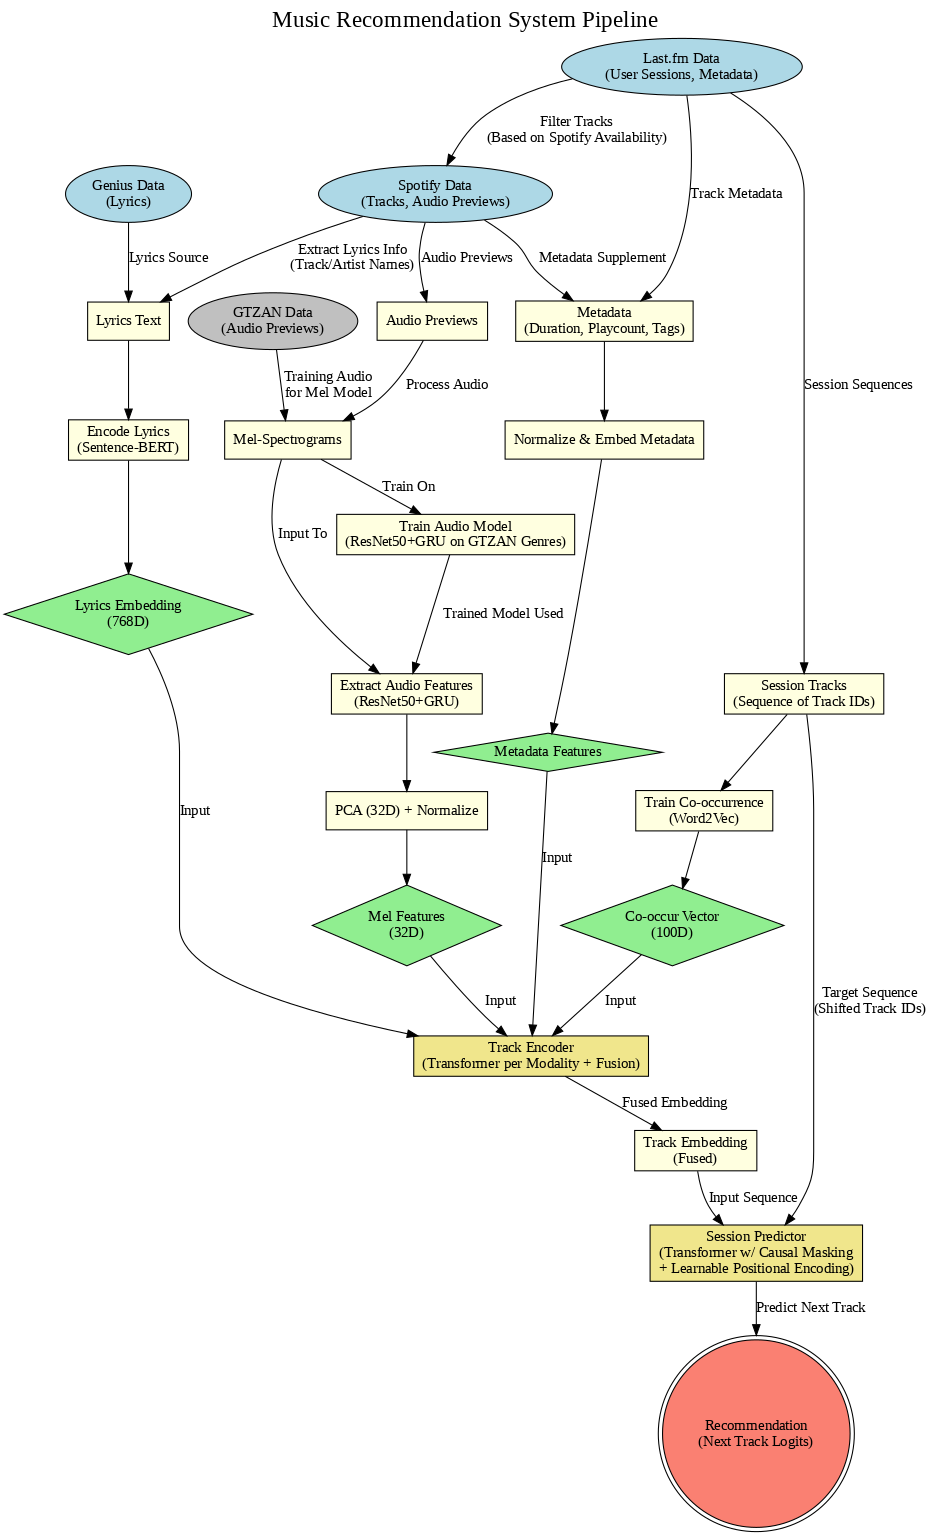

---
---

<a name="2"><a>
# **2. Load Libraries and Dataset**

This section handles the essential setup for our project. We begin by importing all the necessary Python libraries for data manipulation, audio processing, deep learning, and API interactions.

We then load the foundational datasets—Spotify track information, Last.fm listening data, lyrics, and audio previews—which will be processed and used throughout the subsequent phases.



---
<a name="2.1"><a>

## **2.1. Load Libraries**

Here, we import the core libraries needed for the project.

This includes standard data science tools like `Pandas` and `NumPy`, audio analysis with `Librosa`, deep learning frameworks `PyTorch`, text embedding via `Sentence Transformers`, and utilities for API requests and file handling.

In [ ]:
# Installation of missing libraries
!pip install librosa
!pip install lyricsgenius
!pip install transformers
!pip install sentence_transformers
!pip install requests
!pip uninstall -y numpy gensim
!pip install numpy gensim

In [ ]:
import os
import re
import sqlite3
import time
import random
import urllib.request
import requests
import glob
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from urllib.parse import quote
from collections import deque
from concurrent.futures import ThreadPoolExecutor, as_completed
import lyricsgenius
import librosa
import librosa.display
from sentence_transformers import SentenceTransformer
from collections import defaultdict
import seaborn as sns
import math
import warnings
import ast
import csv
import h5py

## ML Library Import
# Scikit-learn library
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# PyTorch library
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data.sampler import SubsetRandomSampler
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import models, transforms
from torchvision.models import resnet50, ResNet50_Weights
import torchaudio.transforms as T
from torch.nn.utils.rnn import pad_sequence


# TensorFlow library
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import TensorBoard

# Gensim library
from gensim.models import Word2Vec

warnings.simplefilter("ignore", category=FutureWarning)

In [ ]:
# API Key Definitions
LASTFM_API_KEY = ''
GENIUS_API_KEY = ''
genius_client_id=''

In [ ]:
# Folders creation to store data
BASE_DIR = 'data'
AUDIO_DIR = os.path.join(BASE_DIR, 'audio_previews')
MEL_DIR = os.path.join(BASE_DIR, 'mel')
LYRICS_DIR = os.path.join(BASE_DIR, 'lyrics')
FEATURES_DIR = os.path.join(BASE_DIR, 'processed_features')
SEQUENCES_DIR = os.path.join(BASE_DIR, 'sequences')

base_consolidated_embedding = 'data_for_submission/'
resnet_weight = base_consolidated_embedding + 'best_model.pth'
session_predictor_weight = base_consolidated_embedding + 'best_session_model.pth'
lyrics_embedding = base_consolidated_embedding + 'lyrics_embeddings.csv'
session_embedding = base_consolidated_embedding + 'session.csv'
tracks_embedding = base_consolidated_embedding + 'tracks.csv'
mel_embedding = base_consolidated_embedding + 'mel_embeddings.csv'


# Spotify audio previews
os.makedirs(AUDIO_DIR, exist_ok=True)
# Mel spectograms
os.makedirs(MEL_DIR, exist_ok=True)
# Genius lyrics
os.makedirs(LYRICS_DIR, exist_ok=True)
# Processed features (spectrograms, embeddings)
os.makedirs(FEATURES_DIR, exist_ok=True)
# Last.fm listening sequences
os.makedirs(SEQUENCES_DIR, exist_ok=True)

print("Directories created successfully:")
print(f"- Audio Previews: {AUDIO_DIR}")
print(f"- Lyrics: {LYRICS_DIR}")
print(f"- Processed Features: {FEATURES_DIR}")
print(f"- Sequences: {SEQUENCES_DIR}")

Directories created successfully:
- Audio Previews: data\audio_previews
- Lyrics: data\lyrics
- Processed Features: data\processed_features
- Sequences: data\sequences


---
<a name="2.2"><a>

## **2.2. Load Dataset**

This section contains the primary data acquisition process with details on the steps involved in gathering the raw data from various sources before we process it into embeddings or sequences later.

This includes fetching Spotify track details, collecting user listening histories and metadata from Last.fm, downloading audio previews, and retrieving lyrics from Genius.


---
<a name="2.2.1"><a>

### **2.2.1 Extract Spotify Data**

This subsection accesses a large Spotify dataset stored in an SQLite database to extract essential track information.

The track name, artist name, and crucially, the `preview_url` for the 30-second audio snippets more specifically.

This data is loaded into a DataFrame and indexed by lowercase track and artist names to allow for quick lookups when cross-referencing with data from other sources like Last.fm.

In [ ]:
def load_spotify_songs(db_file):
    """
    Connect to SQLite database & retrieve Spotify track data.
    Returns DataFrame indexed by (name_lower, artist_lower) for fast lookups.
    """
    query = """
    SELECT t.name, a.name AS artist_name, t.preview_url
    FROM tracks t
    JOIN r_track_artist rta ON t.id = rta.track_id
    JOIN artists a ON rta.artist_id = a.id
    """
    conn = sqlite3.connect(db_file)
    conn.text_factory = bytes
    cursor = conn.cursor()
    cursor.execute(query)
    rows = cursor.fetchall()
    columns = [desc[0] for desc in cursor.description]
    decoded_rows = []
    for row in rows:
        decoded_row = [field.decode('utf-8', errors='replace') if isinstance(field, bytes) else field
                       for field in row]
        decoded_rows.append(decoded_row)
    spotify_df = pd.DataFrame(decoded_rows, columns=columns)
    conn.close()
    spotify_df['name_lower'] = spotify_df['name'].str.lower()
    spotify_df['artist_lower'] = spotify_df['artist_name'].str.lower()
    spotify_df = spotify_df.drop_duplicates(subset=['name_lower', 'artist_lower'])
    spotify_df.set_index(['name_lower', 'artist_lower'], inplace=True)
    print(f"Loaded {len(spotify_df)} unique tracks from Spotify database")
    return spotify_df

# Load Spotify dataset and build lookup keys
spotify_songs_df = load_spotify_songs("data/spotify.sqlite")
spotify_keys = set(spotify_songs_df.index)

---
<a name="2.2.2"><a>

### **2.2.2 Extract Song Previews, Lyrics & Metadata**

This subsection is designed to collect and process music listening data from 100 Last.fm users while extracting metadata and media from external sources like Spotify and Genius.

It starts from a seed user and then uses a breadth-first search (BFS) strategy, expanding through the user’s friends, to gather a network of users (up to a defined target). For each user, it:

* **Fetches recent tracks**: Pulls a user’s listening history via Last.fm’s API.

* **Validates and enriches track data**: Checks if the track appears in a Spotify lookup, downloads preview audio, and fetches additional metadata.

* **Processes sessions**: Groups tracks into listening sessions based on time gaps.

* **Fetches lyrics**: Uses the Genius API to retrieve and save song lyrics.

* **Exports data**: Writes flattened track data and session groupings into CSV files for further analysis.

We decided to get 100 users session data, under the assumption that most will have at least 1 or more sessions, giving us a decent amount of training data. We also define a session as continuous listening to songs until there is over a 30‐minute gap between consecutive tracks.

When the gap between the timestamp of one song and the next exceeds 30 minutes, we consider that the end of one session and the beginning of a new one. Please refer to the docstrings under each function for a description of what each one does.


In [ ]:
# Maximum number of users to process
TARGET_VALID_USERS = 100
# Maximum tracks per user
OVERLAP_TARGET = 2000
# 30 minutes gap allowed between songs
SESSION_GAP_THRESHOLD = 30 * 60

processed_users = set()
user_queue = deque()

def safe_filename(s):
    """ Return a version of the string 's' safe for use as filename.
    Non-alphanumeric chars replaced w/ underscores.
    """
    return ''.join(c if c.isalnum() else '_' for c in s)

def fetch_recent_tracks(username, api_key, limit=200, page=1):
    """
    Fetch recent tracks for a given Last.fm username.
    Returns the JSON response data if successful; otherwise, returns None.
    """
    url = f"http://ws.audioscrobbler.com/2.0/?method=user.getrecenttracks&user={quote(username)}&api_key={api_key}&limit={limit}&page={page}&format=json"
    try:
        response = requests.get(url, timeout=5)
        response.raise_for_status()
        data = response.json()
        if 'error' in data:
            print(f"API error for {username} page {page}: {data.get('message')} (Code: {data.get('error')})")
            return None
        if 'recenttracks' not in data or 'track' not in data['recenttracks']:
            print(f"Invalid response for {username} page {page}")
            return None
        return data
    except requests.exceptions.RequestException as e:
        print(f"Error fetching tracks for {username} page {page}: {e}")
        return None

def fetch_track_details(artist, track, api_key):
    """ Retrieve detailed metadata for track from Last.fm.
    Returns dictionary w/ track details or None on failure.
    """
    url = f"http://ws.audioscrobbler.com/2.0/?method=track.getInfo&api_key={api_key}&artist={quote(artist)}&track={quote(track)}&format=json"
    try:
        response = requests.get(url, timeout=5)
        response.raise_for_status()
        data = response.json()
        if 'error' in data:
            print(f"API error for track '{track}' by '{artist}': {data.get('message')} (Code: {data.get('error')})")
            return None
        return data.get("track", {})
    except requests.exceptions.RequestException as e:
        print(f"Error fetching details for track '{track}' by '{artist}': {e}")
        return None

def get_friends(username, api_key):
    """ Retrieve friend usernames for a given Last.fm user.
    Returns list of friend names, or empty list on failure.
    """
    try:
        url = f"http://ws.audioscrobbler.com/2.0/?method=user.getFriends&user={quote(username)}&api_key={api_key}&format=json"
        response = requests.get(url, timeout=5)
        response.raise_for_status()
        data = response.json()
        return [u.get("name") for u in data.get("friends", {}).get("user", [])]
    except requests.exceptions.RequestException as e:
        print(f"Error fetching friends for {username}: {e}")
        return []

def fetch_lyrics(song):
    """ Use the Genius API via lyricsgenius to fetch lyrics for a song.
    Saves lyrics to a file.
    """
    track_name = song['name']
    # Use Spotify artist name if available; else, fallback to Last.fm artist.
    artist_name = song.get('artist_name', song.get('artist', ''))
    lyrics_file = os.path.join(LYRICS_DIR, f"{safe_filename(track_name)}_{safe_filename(artist_name)}.txt")
    if os.path.exists(lyrics_file):
        print(f"Skipping {track_name} by {artist_name} (lyrics already downloaded)")
        return

    try:
        local_genius = lyricsgenius.Genius(GENIUS_API_KEY, timeout=10)
        song_data = local_genius.search_song(track_name, artist_name)
        if song_data and song_data.lyrics:
            os.makedirs(os.path.dirname(lyrics_file), exist_ok=True)
            with open(lyrics_file, 'w', encoding='utf-8') as f:
                f.write(song_data.lyrics)
            print(f"Saved lyrics to {lyrics_file}")
        else:
            print(f"No lyrics found for {track_name} by {artist_name}")
    except Exception as e:
        print(f"Error fetching lyrics for {track_name} by {artist_name}: {e}")
    finally:
        time.sleep(1)

def try_download_preview(song, audio_dir):
    """ Try download a song's preview from its preview URL.
    Returns True if successful (or if already downloaded), otherwise False.
    """
    preview_url = song.get("preview_url")
    if not preview_url:
        return False
    safe_track = safe_filename(song["name"])
    safe_artist = safe_filename(song["artist"])
    file_path = os.path.join(audio_dir, f"{safe_track}_{safe_artist}.mp3")
    if os.path.exists(file_path):
        print(f"Skipping {song['name']} by {song['artist']} (preview already downloaded)")
        return True
    try:
        urllib.request.urlretrieve(preview_url, file_path)
        print(f"Downloaded preview: {file_path}")
        return True
    except Exception as e:
        print(f"Failed to download preview from {preview_url}: {e}")
        return False

In [ ]:
def segment_user_sessions(tracks, gap_threshold=SESSION_GAP_THRESHOLD):
    """ Segment tracks into sessions based on time gaps between them.
    Returns list of sessions, each being a list of tracks.
    """
    # track filtering
    tracks_with_time = [t for t in tracks if "date" in t and isinstance(t["date"], dict) and t["date"].get("uts")]
    tracks_with_time.sort(key=lambda t: int(t["date"]["uts"]))
    sessions, current_session, prev_ts = [], [], None
    for t in tracks_with_time:
        cur_ts = int(t["date"]["uts"])
        if prev_ts is None or (cur_ts - prev_ts) <= gap_threshold:
            current_session.append(t)
        else:
            sessions.append(current_session)
            current_session = [t]
        prev_ts = cur_ts
    if current_session:
        sessions.append(current_session)
    return sessions

def flatten_track_with_id(track, trackid):
    """ Flatten track's nested data into single dictionary w/ given trackid. """
    flat = {"trackid": trackid}
    flat["name"] = track.get("name", "")
    artist = track.get("artist", {})
    flat["artist"] = artist.get("#text", "") if isinstance(artist, dict) else str(artist)
    album = track.get("album", {})
    flat["album"] = album.get("#text", "") if isinstance(album, dict) else str(album)
    if "date" in track and isinstance(track["date"], dict):
        date_text = track["date"].get("#text", "")
        if "," in date_text:
            date_part, time_part = date_text.split(",", 1)
            flat["date"] = date_part.strip()
            flat["time"] = time_part.strip()
        else:
            flat["date"] = date_text
            flat["time"] = ""
    else:
        flat["date"] = flat["time"] = ""
    detailed = track.get("detailed_info", {})
    if isinstance(detailed, dict):
        tags = detailed.get("toptags", {}).get("tag", [])
        if isinstance(tags, dict):
            tags = [tags]
        flat["tags"] = ", ".join([t.get("name", "") for t in tags if isinstance(t, dict)])
        flat["duration"] = detailed.get("duration", "")
        flat["playcount"] = detailed.get("playcount", "")
    else:
        flat["tags"] = flat["duration"] = flat["playcount"] = ""
    return flat

In [ ]:
def collect_user_data(username, api_key, spotify_keys):
    """ For a user:
      - Fetch recent tracks page-by-page.
      - For each track in the Spotify lookup, validate the preview URL & try download.
      - Enrich track with detailed metadata & fetch lyrics.
      - Collect overlapping tracks until reaching OVERLAP_TARGET.
      - Save track data & session segmentation to CSV files.
    """
    print(f"Collecting data for user '{username}'...")
    overlap_tracks = []
    page = 1
    while True:
        data = fetch_recent_tracks(username, api_key, page=page)
        if not data:
            break
        tracks = data["recenttracks"]["track"]
        if not tracks:
            break
        total_pages = int(data["recenttracks"]["@attr"].get("totalPages", page))
        for track in tracks:
            t_name = track.get("name", "").lower()
            artist_field = track.get("artist", {})
            a_name = artist_field.get("#text", "").lower() if isinstance(artist_field, dict) else str(artist_field).lower()
            key = (t_name, a_name)
            if key not in spotify_keys:
                continue

            # preview URL from the Spotify data retrieval and activation
            preview_url = spotify_songs_df.loc[key, 'preview_url']
            if not preview_url:
                print(f"Skipping {track.get('name')} by {a_name} (no preview URL)")
                continue
            track['preview_url'] = preview_url

            # validates that the preview can be downloaded
            if not try_download_preview(track, AUDIO_DIR):
                print(f"Skipping {track.get('name')} by {a_name} (preview download failed)")
                continue

            # metadata from Last.fm added to track
            details = fetch_track_details(
                artist_field.get("#text", "") if isinstance(artist_field, dict) else str(artist_field),
                track.get("name", ""),
                api_key
            )
            if details:
                track["detailed_info"] = details

            # artist_name field using Spotify data
            track['artist_name'] = spotify_songs_df.loc[key, 'artist_name']
            fetch_lyrics(track)
            overlap_tracks.append(track)
            if len(overlap_tracks) >= OVERLAP_TARGET:
                break
        if len(overlap_tracks) >= OVERLAP_TARGET or page >= total_pages:
            break
        page += 1
        time.sleep(1.5)

    print(f"User '{username}' has {len(overlap_tracks)} overlapping tracks.")

    # sequential track IDs assignment
    for i, track in enumerate(overlap_tracks, start=1):
        track["trackid"] = i

    # track data to csv export
    flat_tracks = [flatten_track_with_id(track, track["trackid"]) for track in overlap_tracks]
    tracks_csv_file = os.path.join(SEQUENCES_DIR, f"{username}_tracks.csv")
    pd.DataFrame(flat_tracks).to_csv(tracks_csv_file, index=False)
    print(f"Saved user tracks CSV: {tracks_csv_file}")

    # tracks segented into sessions and exported
    sessions = segment_user_sessions(overlap_tracks)
    session_rows = [{"session_id": i + 1, "track_list": ", ".join(str(t.get("trackid", "")) for t in session)}
                    for i, session in enumerate(sessions)]
    sessions_csv_file = os.path.join(SEQUENCES_DIR, f"{username}_sessions.csv")
    pd.DataFrame(session_rows).to_csv(sessions_csv_file, index=False)
    print(f"Saved user sessions CSV: {sessions_csv_file}")

    return {"username": username, "tracks": overlap_tracks, "sessions": sessions}

def process_user(username, spotify_keys):
    """ Process single user by collecting their data & retrieving their friend list. """
    try:
        user_data = collect_user_data(username, LASTFM_API_KEY, spotify_keys)
    except Exception as e:
        print(f"Error processing user '{username}': {e}")
        return []
    return get_friends(username, LASTFM_API_KEY)

In [ ]:
def song_collection_execution():
    """ Function to perform final user processing execution. """
    seed_username = "RJ"
    user_queue.append(seed_username)
    max_workers = 3
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        while user_queue and len(processed_users) < TARGET_VALID_USERS:
            futures = []
            while user_queue and len(futures) < max_workers:
                user = user_queue.popleft()
                if user in processed_users:
                    continue
                processed_users.add(user)
                futures.append(executor.submit(process_user, user, spotify_keys))
            for future in as_completed(futures):
                try:
                    for friend in future.result():
                        if friend not in processed_users:
                            user_queue.append(friend)
                except Exception as e:
                    print(f"Error in processing future: {e}")
            print(f"BFS queue size: {len(user_queue)} | Processed users: {len(processed_users)}")
            time.sleep(1)
            if not user_queue:
                print("User queue exhausted. Ending BFS.")
                break

if __name__ == "__main__":
    song_collection_execution()

---
<a name="2.2.3"><a>

### **2.2.3 Create Global Track & Session List**


This subsection consolidates the data collected for individual users into unified global lists.

1.  **Global Tracks (`tracks.csv`):**
    *   It reads all `*_tracks.csv` files generated per user.
    *   Assigns a unique **global track ID** to each song (identified by name and artist), ensuring each song has one ID across the dataset.
    *   Saves this consolidated list of unique tracks and metadata into `tracks.csv`.

2.  **Global Sessions (`sessions.csv`):**
    *   It reads all `*_sessions.csv` files.
    *   Replaces the user-specific local track IDs within each session with their corresponding **global track IDs** generated previously.
    *   Assigns a unique **global session ID** to each session.
    *   Saves this consolidated list of sessions, now using global track IDs, into `sessions.csv`.

This process standardizes the track references across users, making the data ready for training where tracks need a consistent identifier.


In [ ]:
track_files = glob.glob(os.path.join(SEQUENCES_DIR, "*_tracks.csv"))
session_files = glob.glob(os.path.join(SEQUENCES_DIR, "*_sessions.csv"))
global_tracks = []
track_key_to_global_id = {}
local_to_global_track = {}
next_global_track_id = 1

# Parse all {username}_tracks.csv & create global tracks.csv
for track_file in track_files:
    base = os.path.basename(track_file)
    username = base.replace("_tracks.csv", "")

    with open(track_file, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            local_id = row["trackid"].strip()

            track_key = (
                row["name"].strip(),
                row["artist"].strip()
            )

            if track_key not in track_key_to_global_id:
                track_key_to_global_id[track_key] = next_global_track_id
                global_tracks.append({
                    "track_id": next_global_track_id,
                    "name": row["name"],
                    "artist": row["artist"],
                    "album": row["album"],
                    "date": row["date"],
                    "time": row["time"],
                    "tags": row["tags"],
                    "duration": row["duration"],
                    "playcount": row["playcount"]
                })
                next_global_track_id += 1

            global_id = track_key_to_global_id[track_key]
            local_to_global_track[(username, local_id)] = global_id

tracks_output_file = os.path.join(SEQUENCES_DIR, "tracks.csv")
with open(tracks_output_file, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=[
        "track_id", "name", "artist", "album", "date", "time",
        "tags", "duration", "playcount"
    ])
    writer.writeheader()
    for track in global_tracks:
        writer.writerow(track)

# Combine sessions into global session list
global_sessions = []
next_global_session_id = 1

for session_file in session_files:
    base = os.path.basename(session_file)
    username = base.replace("_sessions.csv", "")
    with open(session_file, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            local_ids = row["track_list"].split(",")

            global_ids = []
            for local_id in local_ids:
                local_id_stripped = local_id.strip()
                global_id = local_to_global_track.get((username, local_id_stripped))
                if global_id is None:
                    continue
                global_ids.append(str(global_id))

            new_track_list = ",".join(global_ids)
            global_sessions.append({
                "session_id": next_global_session_id,
                "track_list": new_track_list
            })
            next_global_session_id += 1

sessions_output_file = os.path.join(SEQUENCES_DIR, "sessions.csv")
with open(sessions_output_file, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["session_id", "track_list"])
    writer.writeheader()
    for session in global_sessions:
        writer.writerow(session)

---
---
<a name="pretraining"></a>
# **3. Pre-Training Phase**

In this section, we use the data collected in ***Section 2.0*** to build our multi-modal track embeddings, combining three different perspectives:

1. **Audio (Mel-spectrograms):**  
   We convert each track’s audio preview into a mel-spectrogram (***Section 3.1***). These spectrograms capture the time–frequency characteristics of the audio, which we can then feed into a ResNet feature extractor to produce a numerical **audio embedding**.

2. **Lyrics (BERT-based embedding):**  
   We take each track’s lyrics (if available) and pass them through a pretrained BERT model (***Section 3.2***). BERT transforms the text into a **lyrical embedding** that reflects semantic and contextual information in the lyrics.

3. **Listening Co-occurrence (Word2Vec):**  
   Separately, we look at how tracks appear together in users’ listening sessions. By training a Word2Vec model on these sequences (***Section 3.3***), we generate a **co-occurrence embedding** for each track, capturing how often and in what context it’s listened to alongside other tracks.

Once we have these three embeddings—audio, lyrics, and co-occurrence— plus the song metadata from last.fm, we can combine them by stacking them (***Section 4.4***) to form a single rich vector representation for each track.

The final, multi-modal embedding incorporates acoustic features, lyrical semantics, and user behavior patterns, enabling more nuanced comparisons and recommendations in later stages of the project.

---

<a name="mel-embed"></a>
## **3.1 Mel-Spectogram Embedding Creation**

This subsection details the process for generating our **audio embeddings**.
1.  **Spectrogram Generation (`3.1.1`):** Convert the 30 second audio preview files into mel-spectrogram images. These images represent the audio's frequency content over time.
2.  **Embedding Training (`3.1.2` onwards):** Using spectrograms directly is inefficient thus we train a neural network (ResNet50 + GRU) on the GTZAN genre classification dataset. The output from an intermediate layer of this trained model gives a vector—the **mel embedding**—for each track's audio.


---
<a name="3.1.1"><a>

### **3.1.1 Mel-Spectrograms Creation**

This subsection converts an audio file into a mel-spectrogram image.

1. **Load the Audio:**  
   It uses **librosa.load** to read the audio file from the specified `audio_path` and set a target sample rate (`sr`).

2. **Generate the Mel-Spectrogram:**  
   - **`librosa.feature.melspectrogram`** processes the raw audio to create a **frequency vs. time** representation using the mel scale.  
   - **`librosa.power_to_db`** converts that spectrogram to a **decibel scale**, making it easier to visualize.

3. **Save the Spectrogram:**  
   If `save_path` is provided, the function uses **matplotlib** to plot and save the spectrogram image without axes or extra padding.

4. **Error Handling:**  
   In case issues arise (ex. unsupported file), the exception is raised with the error message shown.

**Additional:**
- Processes files in batches of 100.
- **Frees memory** with `gc.collect()` after each batch to reduce resource usage.

In [ ]:
def createMelSpectrogram(audio_path, save_path="", n_mels=128, hop_length=512, n_fft=2048, sr=22050):
    try:
        y, sr_loaded = librosa.load(audio_path, sr=sr)
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, hop_length=hop_length, n_fft=n_fft)
        S_dB = librosa.power_to_db(S, ref=np.max)

        if save_path:
            plt.figure(figsize=(5, 5))
            librosa.display.specshow(S_dB, sr=sr, hop_length=hop_length, cmap="inferno")
            plt.axis("off")
            plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
            plt.close('all')

    except Exception as e:
        print(f"Error processing {audio_path}: {e}")

# retrieving all audio files
audio_files = glob.glob(os.path.join(LYRICS_DIR, "*.mp3"))
print(f"Found {len(audio_files)} audio files in {LYRICS_DIR}")

batch_size = 100
# batch processing files
for batch_start in range(0, len(audio_files), batch_size):
    batch_files = audio_files[batch_start: batch_start + batch_size]
    for i, audio_path in enumerate(batch_files, start=batch_start):
        base_name = os.path.splitext(os.path.basename(audio_path))[0]
        save_path = os.path.join(MEL_DIR, base_name + ".png")
        if os.path.exists(save_path):
            continue

        createMelSpectrogram(audio_path, save_path=save_path)
    # memory clean after batch processing
    gc.collect()

---
<a name="3.1.2"><a>

### **3.1.2 Mel Embedding Training: Learning Audio Features**

This subsection details all the necessary components to implement, train, validate, visualize and extract the learned embeddings from our Neural Network Model.

**Training Strategy & Dataset:**

*   **Why Train?** WE need to adapt the the pretrained model to perform well for **music genre classification**. By learning to distinguish between genres, the model will represent key acoustic features within its internal layers.
*   **Dataset:** We utilize the **GTZAN dataset** which consists of 1000 30-second audios, evenly distributed across 10 distinct genres: *blues, classical, country, disco, hiphop, jazz, metal, pop, reggae, and rock*.
*   **Feature Extraction:** The final **mel embeddings** used in our main pipeline are *not* the genre predictions themselves, but the output features generated by the model layer *immediately preceding* the final layer.

**Model Architecture: ResNet50 + GRU Overview:**

1.  **Input - Mel-Spectrograms:** Raw audio previews are first converted into **mel-spectrograms**.
2.  **CNN Backbone - ResNet50:**
    *   We use a **ResNet50** model (pre-trained on ImageNet) as our primary feature extractor for the spectrogram image. It was chosen over AlexNet due to its performance and computational efficiency.
    *   The ResNet processes the spectrogram, capturing hierarchical spatial features.
3.  **Frequency Pooling:** To prepare for sequential modeling, we apply average pooling across the **frequency dimension (H)** of the ResNet's output. This condenses information for each time step.
4.  **Sequential Modeling - GRU:**
    *   The resulting sequence (shape: `Batch x Features x Time`) is fed into a **GRU (Gated Recurrent Unit)** layer.
    *   The GRU processes the sequence along the **time dimension (W)**, capturing temporal patterns.
5.  **Final Embedding:** The output sequence from the GRU is averaged across the time dimension to produce a fixed-size vector for each preview. This vector constitutes the **mel embedding** used in later sections.
6.  **Training Classifier:** *For training on GTZAN*, a linear layer is added after the GRU to predict one of 10 genres. This layer is **discarded** after training; only the GRU output is retained as embeddings.

**Note:** A mel-spectrogram is a type of audio feature representation that shows how the energy of different frequency components in a sound signal changes over time, using the Mel scale -— a scale that more closely aligns with how humans perceive pitch. This can be turned in a form of picture and then passed into a cnn. An example of a mel-spectogram can be seen below.
![Mel Spectrogram Image](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*Dbc9s0KfznzFYO0Q7OOOWg.png)



---
<a name="3.1.2.1"><a>
### **3.1.2.1 Loading & Processing GZAN Functions**

This subsection details the functions used to prepare the **GTZAN dataset** for training our audio feature extractor model.

*   **Mel-Spectrogram Creation & Saving:**
    *   We define functions to convert raw audio (`.wav` files from GTZAN) into **mel-spectrograms**.
    *   To optimize time, these spectrograms are precomputed and saved into an **HDF5 file** using the `save_spectrograms` function. This avoids repeated computation.
    *   A helper function `get_dataset_paths` is used to navigate the datasets within the HDF5 file.

*   **Data Augmentation:**
    *   Functions like `AudioTransform` and `SpecAugment` were created to apply **time stretching, pitch shifting, and spectrogram masking**.
    *   However, due to **training time constraints** with the available hardware (Nvidia A100) we decided not to augment as training time with the non-augmented dataset was substantial. Another consideration in this decision was the **difficulty in visually verifying** audio augmentations compared to image augmentations, thus would be unable to ensure model stability and confidence in learned features.

*   **GZAN Dataset Class (`GTZANDataset`):**
    *   A custom PyTorch `Dataset` class is  to load the precomputed mel-spectrograms directly from the HDF5 file. This class handles mapping file paths to genre labels.

*   **Normalization & Batching:**
    *   The `compute_mean_std` function calculates the mean and standard deviation across the spectrogram dataset for normalization, to help stabilize model training.
    *   The `pad_collate` function handles sequences of different lengths by padding them to the maximum length within the batch, essential for the GRU layer. It filters out any `None` samples that result from data loading issues.

In [ ]:
# Audio Transform Class
class AudioTransform:
    """Applies random time stretching & pitch shifting to audio signals."""
    def __init__(self, rate_range=(0.8, 1.2), pitch_shift_range=(-2, 2), sr=22050, n_mels=256):
        self.rate_range = rate_range
        self.pitch_shift_range = pitch_shift_range
        self.sr = sr

    def __call__(self, y):
        rate = np.random.uniform(*self.rate_range)
        y = librosa.effects.time_stretch(y, rate=rate)
        n_steps = np.random.uniform(*self.pitch_shift_range)
        y = librosa.effects.pitch_shift(y, sr=self.sr, n_steps=n_steps)
        return y

def save_spectrograms(audio_dir, hdf5_path, n_mels=256, sr=22050, hop_length=256, n_fft=2048):
    """ Precompute mel spectrograms for all audio files & save in an HDF5 file.
    Args:
        audio_dir: Directory containing audio files
        hdf5_path: Path to save HDF5 file
        n_mels: Number of mel bins
        sr: Sample rate
        hop_length: Hop length for spectrogram
        n_fft: FFT window size """
    if not os.path.exists(hdf5_path):
        with h5py.File(hdf5_path, 'w') as f:
            for root, _, files in os.walk(audio_dir):
                for file in files:
                    if file.endswith('.wav'):
                        audio_path = os.path.join(root, file)
                        try:
                            y, _ = librosa.load(audio_path, sr=sr)
                            S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, hop_length=hop_length, n_fft=n_fft)
                            S_dB = librosa.power_to_db(S, ref=np.max)
                            f.create_dataset(audio_path, data=S_dB)
                        except Exception as e:
                            print(f"Error processing {audio_path}: {e}")

def get_dataset_paths(hdf5_file):
  """ Gets list of dataset paths stored in HDF5 file. """
    dataset_paths = []
    def visit_func(name, obj):
        if isinstance(obj, h5py.Dataset):
            dataset_paths.append(name)
    hdf5_file.visititems(visit_func)
    return dataset_paths

In [ ]:
# Custom Dataset Class
class GTZANDataset(Dataset):
    """ PyTorch Dataset class for loading precomputed mel spectrograms from HDF5 file. """
    def __init__(self, hdf5_path, file_paths=None, spec_transform=None):
        self.hdf5_path = hdf5_path
        if spec_transform is not None:
            self.spec_transform = spec_transform
        else:
            self.spec_transform = lambda x: x

        if file_paths is None:
            with h5py.File(hdf5_path, 'r') as f:
                audio_paths = get_dataset_paths(f)

            def get_genre_from_path(path):
                parts = path.split('/')
                if len(parts) >= 2:
                    return parts[-2]
                else:
                    return None

            genres = sorted(set([get_genre_from_path(path) for path in audio_paths if get_genre_from_path(path) is not None]))
            self.classes = genres
            self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
            self.file_paths = [
                (path, self.class_to_idx[get_genre_from_path(path)])
                for path in audio_paths if get_genre_from_path(path) in self.class_to_idx
            ]
        else:
            self.file_paths = file_paths
            genres = sorted(set([os.path.basename(os.path.dirname(path)) for path, _ in file_paths]))
            self.classes = genres
            self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

    def __len__(self):
        """ Return the number of samples in dataset."""
        return len(self.file_paths)

    def __getitem__(self, idx):
        """ Get sample from dataset. """
        audio_path, label = self.file_paths[idx]
        try:
            with h5py.File(self.hdf5_path, 'r') as f:
                spectrogram = f[audio_path][:]
            spectrogram = torch.tensor(spectrogram, dtype=torch.float32).unsqueeze(0)
            if self.spec_transform is not None:
                spectrogram = self.spec_transform(spectrogram)

            return spectrogram, label
        except KeyError:
            print(f"Warning: Spectrogram for {audio_path} not found in HDF5 file.")
            return None, None

In [ ]:
# Normalization Computation
def compute_mean_std(dataset):
  """ Computes the mean & standard deviation of spectrograms in dataset for normalization. """
    spectrograms = []
    for i in range(len(dataset)):
        spec, _ = dataset[i]
        if spec is not None:
            spectrograms.append(spec.view(-1))
    if spectrograms:
        spectrograms = torch.cat(spectrograms)
        mean = spectrograms.mean().item()
        std = spectrograms.std().item() if spectrograms.std().item() > 0 else 1
        return mean, std
    return 0, 1

# Spectrogram Augmentation Class
class SpecAugment:
    """Applies time & frequency masking to spectrograms."""
    def __init__(self, time_mask_param=20, freq_mask_param=20):
        self.time_mask = T.TimeMasking(time_mask_param=time_mask_param)
        self.freq_mask = T.FrequencyMasking(freq_mask_param=freq_mask_param)

    def __call__(self, spectrogram):
        spectrogram = self.time_mask(spectrogram)
        spectrogram = self.freq_mask(spectrogram)
        return spectrogram

def pad_collate(batch):
  """ Collates batch data, padding spectrograms to max length & handles None values. """
    batch = [item for item in batch if item[0] is not None] # Filter None vals from failed audio loads
    if not batch:
        return None, None

    spectrograms, labels = zip(*batch) #separate spectrograms & labels
    n_mels = spectrograms[0].shape[1] #check they have same n_mels
    for spec in spectrograms:
        if spec.shape[1] != n_mels:
            raise RuntimeError(f"Inconsistent n_mels: expected {n_mels}, got {spec.shape[1]}")

    spectrograms = [spec.squeeze(0).transpose(0, 1) for spec in spectrograms] #squeeze channel dim & transpose --> (time_steps, n_mels)
    # Pad sequences along time_steps
    spectrograms_padded = pad_sequence(spectrograms, batch_first=True, padding_value=0)
    spectrograms_padded = spectrograms_padded.transpose(1, 2)
    spectrograms_padded = spectrograms_padded.unsqueeze(1)  # add channel dims back
    labels = torch.tensor(labels, dtype=torch.long) #tensor conversion

    return spectrograms_padded, labels

---
<a name="3.1.2.2"><a>

### **3.1.2.2 Model Architecture, Training & Evaluation Functions**

This subsection outlines the model architecture and the functions used for training and evaluating on the GTZAN dataset.

*   **Model Architecture (`ResNet50WithGRU`):**
    *   We utilize a **ResNet50** model, pre-trained on ImageNet, as the base feature extractor.
    *   The **first convolutional layer** is modified to accept 1-channel input (mel-spectrograms are grayscale).
    *   The original **average pooling and fully connected (FC)** layers are removed.
    *   The output feature map from ResNet's convolutional layers ( `batch_size x 2048 x H x W`) is processed with **H represents frequency** and **W represents time**.
    *   We apply **average pooling across the frequency dimension (H)**, resulting in `batch_size x 2048 x W`.
    *   This sequence is fed to a **bidirectional GRU layer** to capture temporal dependencies along the time dimension (W), outputting `batch_size x W x (2 * hidden_size)`.
    *   The GRU output is **averaged over the time steps (W)** to get a fixed-size feature vector (`batch_size x (2 * hidden_size)`).
    *   ***For training only:*** A final **FC layer** classifies these features into the 10 GTZAN genres. The weights learned up to the layer *before* this FC layer are what we use as the **mel-embedding extractor** for our main recommendation task.
    *   **Note:** The code includes commented-out lines for freezing the ResNet weights. In our final run, these weights were *not* frozen, allowing the ResNet layers to fine-tune during training.

*   **Training Function (`train_model`):**
    *   Handles the training loop over epochs.
    *   Implements **early stopping** based on validation loss to prevent overfitting.
    *   Saves the best-performing model weights.

*   **Evaluation Function (`evaluate_model`):**
    *   Evaluates the trained model on the validation set.
    *   Calculates validation loss, accuracy, generates a **confusion matrix**, and computes a **classification report**.

*   **Feature Extraction & Visualization:**
    *   `extract_features`: Uses the trained model (the layers *before* the final classification FC layer) to extract learned audio embeddings.
    *   `visualize_latent_space`: Applies **PCA** to reduce the high-dimensional embeddings to 2D and creates a scatter plot to show genre clustering.
    *   `visualize_performance`: Displays the confusion matrix heatmap and prints the detailed classification report for analysis.

In [ ]:
# Model Architecture
class ResNet50WithGRU(nn.Module):
    def __init__(self, num_classes=10, hidden_size=256, num_layers=1, dropout_rate=0.5):
        super(ResNet50WithGRU, self).__init__()
        self.resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # Freeze all ResNet parameters
        #for param in self.resnet.parameters():
        #    param.requires_grad = False

        # Remove original avgpool and fc layers
        del self.resnet.avgpool
        del self.resnet.fc

        # Add GRU - temporal modeling
        self.gru = nn.GRU(2048, hidden_size, num_layers=num_layers, batch_first=True, bidirectional=True)
        # Add dropout - regularization
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(2*hidden_size, num_classes)

    def forward(self, x):
        # Pass through ResNet50 feature extractor
        x = self.resnet.conv1(x)
        x = self.resnet.bn1(x)
        x = self.resnet.relu(x)
        x = self.resnet.maxpool(x)
        x = self.resnet.layer1(x)
        x = self.resnet.layer2(x)
        x = self.resnet.layer3(x)
        x = self.resnet.layer4(x)
        # Pool over frequency dim
        x = x.mean(dim=2)
        # GRU preparation
        x = x.permute(0, 2, 1)
        x, _ = self.gru(x)
        # Avg. over time steps
        x = x.mean(dim=1)
        x = self.dropout(x)
        return self.fc(x)

    def extract_features(self, x):
        # extract features for visualization
        x = self.resnet.conv1(x)
        x = self.resnet.bn1(x)
        x = self.resnet.relu(x)
        x = self.resnet.maxpool(x)
        x = self.resnet.layer1(x)
        x = self.resnet.layer2(x)
        x = self.resnet.layer3(x)
        x = self.resnet.layer4(x)
        x = x.mean(dim=2)
        x = x.permute(0, 2, 1)
        x, _ = self.gru(x)
        x = x.mean(dim=1)
        return x


In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=50, patience=10):
  """ Trains model, logs metrics, implements early stopping & saves the best model state. """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    best_val_loss = float('inf')
    epochs_no_improve = 0
    val_losses = []
    train_losses = []
    val_accuracies = []
    train_accuracies = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0.0
        total_train = 0.0
        valid_batches = 0
        for inputs, labels in train_loader:
            if inputs is None or labels is None:
                continue
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, preds = torch.max(outputs, 1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)
            running_loss += loss.item()
            valid_batches += 1
        train_acc= correct_train / total_train if total_train > 0 else float('nan')
        train_accuracies.append(train_acc)
        train_loss = running_loss / valid_batches if valid_batches > 0 else float('nan')
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        correct_val = 0.0
        total_val = 0.0
        valid_val_batches = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                if inputs is None or labels is None:
                    continue
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)
                valid_val_batches += 1

        val_acc = correct_val / total_val if total_val > 0 else float('nan')
        val_accuracies.append(val_acc)
        val_loss = val_loss / valid_val_batches if valid_val_batches > 0 else float('nan')
        val_losses.append(val_loss)

        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Val Loss: {val_loss:.4f}')
        scheduler.step(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print('Early stopping triggered')
                break

    return train_losses, train_accuracies, val_losses, val_accuracies

In [ ]:
def evaluate_model(model, val_loader, criterion):
  """ Evaluates model on validation set, returning loss, accuracy, confusion matrix & classification report. """
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0.0
    valid_batches = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            if inputs is None or labels is None:
                continue
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            valid_batches += 1

            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = total_loss / valid_batches if valid_batches > 0 else float('nan')
    val_accuracy = accuracy_score(all_labels, all_preds)
    conf_matrix = confusion_matrix(all_labels, all_preds)
    class_report = classification_report(all_labels, all_preds, target_names=val_loader.dataset.classes)

    return val_loss, val_accuracy, conf_matrix, class_report

# Feature Extraction Function
def extract_features(model, data_loader):
  """ Extracts features (embeddings) using the model's feature extraction part (before final classifier). """
    model.eval()
    features = []
    labels = []
    with torch.no_grad():
        for inputs, lbls in data_loader:
            if inputs is None or lbls is None:
                continue
            inputs = inputs.to(device)
            feats = model.extract_features(inputs)
            features.append(feats.cpu().numpy())
            labels.append(lbls.numpy())
    features = np.concatenate(features)
    labels = np.concatenate(labels)
    return features, labels

def visualize_latent_space(features, labels, classes, model_name="best_model"):
  """ Performs PCA on features & creates 2D scatter plot colored by labels to visualize latent space. """
    pca = PCA(n_components=2)
    latent_2d = pca.fit_transform(features)
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=latent_2d[:, 0], y=latent_2d[:, 1], hue=labels, palette="tab10", legend="full")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title(f"Latent Space Visualization (PCA) {model_name}")
    plt.legend(title="Genre", labels=classes)
    plt.show()


def visualize_performance(conf_matrix, val_accuracy, class_report, classes):
  """ Displays the confusion matrix as a heatmap & prints the classification report. """
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'Val Set Confusion Matrix\nAccuracy: {val_accuracy:.4f}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    print("\nClassification Report:")
    print(class_report)

---
<a name="3.1.2.3"><a>

### **3.1.2.3 Training Execution & Final Model Selection**

This subsection executes the training, evaluation & visualization functions for the model using the GTZAN dataset.

*   **Setup:**
    *   Defines training configurations like `batch_size`, and `patience` for early stopping.
    *   Calls `save_spectrograms` to ensure spectrograms are created.

*   **Data Preparation:**
    *   Creates the full `GTZANDataset`.
    *   Computes the **mean and standard deviation** for normalization using `compute_mean_std`.
    *   Splits the dataset into **training & validation sets** (80/20 split).
    *   Creates separate `GTZANDataset` instances and `DataLoader`s for training & validation, using `pad_collate` function for batching.

*   **Training Loop:**
    *   Initializes the `ResNet50WithGRU` model, loss function (`CrossEntropyLoss`), optimizer (`AdamW`), and learning rate scheduler (`ReduceLROnPlateau`).
    *   Runs the `train_model` function which trains the model, evaluates on the validation set, and saves the best model (***lowest val loss***) weights to `best_model.pth`.

*   **Final Evaluation & Visualization:**
    *   Loads the best saved model weights.
    *   Uses `evaluate_model` to get the final validation loss, accuracy, confusion matrix, & classification report.
    *   Calls `extract_features` to get the validation set embeddings using the trained feature extractor model component.
    *   Visualizes the feature space using `visualize_latent_space`.
    *   Displays the performance metrics using `visualize_performance` (confusion matrix & classification report).

The saved `best_model.pth` file is then used later for generating mel-embeddings for the recommendation task tracks.


<ipython-input-7-148ec4d6d1dc>:71: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(audio_path, sr=sr)


Error processing /content/drive/My Drive/MIE1517 Group Project/data/gzan/genres_original/jazz/jazz.00054.wav: 
Computed mean: -45.7232, std: 15.4728

=== Experiment 1 ===

Variation 1: {'hidden_size': 256, 'num_layers': 1, 'dropout_rate': 0.5}


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 219MB/s]


Epoch 1/26, Train Loss: 1.8930, Train Acc: 0.3292, Val Acc: 0.1300, Val Loss: 2.8824
Epoch 2/26, Train Loss: 1.4669, Train Acc: 0.4831, Val Acc: 0.4100, Val Loss: 1.7018
Epoch 3/26, Train Loss: 1.3351, Train Acc: 0.5181, Val Acc: 0.4650, Val Loss: 1.4772
Epoch 4/26, Train Loss: 1.1480, Train Acc: 0.5832, Val Acc: 0.1700, Val Loss: 3.8575
Epoch 5/26, Train Loss: 1.0216, Train Acc: 0.6458, Val Acc: 0.2950, Val Loss: 2.7623
Epoch 6/26, Train Loss: 0.9082, Train Acc: 0.6771, Val Acc: 0.3850, Val Loss: 1.7092
Epoch 7/26, Train Loss: 0.8197, Train Acc: 0.7209, Val Acc: 0.4800, Val Loss: 1.8235
Epoch 8/26, Train Loss: 0.7380, Train Acc: 0.7284, Val Acc: 0.2300, Val Loss: 2.7787
Epoch 9/26, Train Loss: 0.6057, Train Acc: 0.7947, Val Acc: 0.4850, Val Loss: 1.7173
Epoch 10/26, Train Loss: 0.5682, Train Acc: 0.8073, Val Acc: 0.7350, Val Loss: 0.8158
Epoch 11/26, Train Loss: 0.4581, Train Acc: 0.8335, Val Acc: 0.6600, Val Loss: 1.1244
Epoch 12/26, Train Loss: 0.4609, Train Acc: 0.8473, Val Acc: 0.

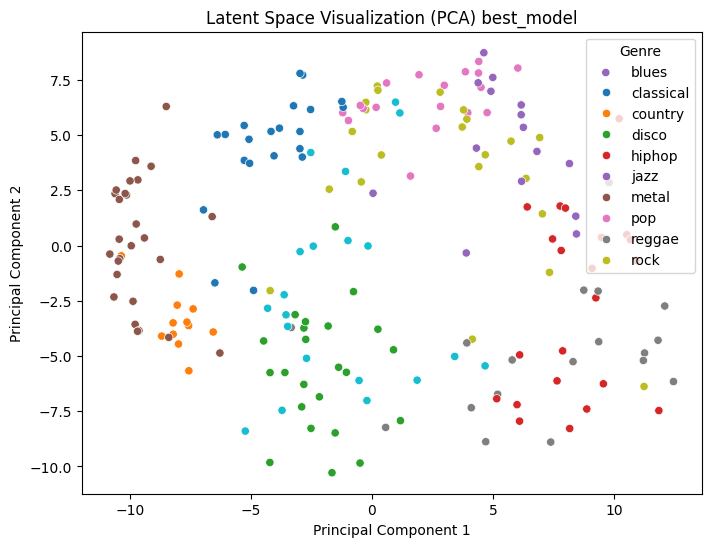

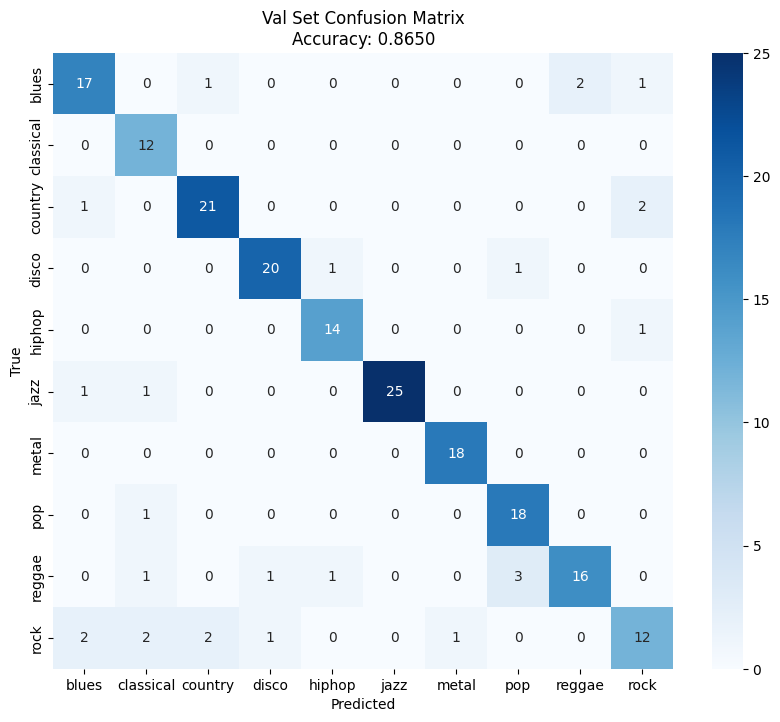


Classification Report:
              precision    recall  f1-score   support

       blues       0.81      0.81      0.81        21
   classical       0.71      1.00      0.83        12
     country       0.88      0.88      0.88        24
       disco       0.91      0.91      0.91        22
      hiphop       0.88      0.93      0.90        15
        jazz       1.00      0.93      0.96        27
       metal       0.95      1.00      0.97        18
         pop       0.82      0.95      0.88        19
      reggae       0.89      0.73      0.80        22
        rock       0.75      0.60      0.67        20

    accuracy                           0.86       200
   macro avg       0.86      0.87      0.86       200
weighted avg       0.87      0.86      0.86       200


Experiment 1 Results:
Config: {'hidden_size': 256, 'num_layers': 1, 'dropout_rate': 0.5}, Val Acc: 0.8650, Val Loss: 0.4013, Train Acc: 0.9625


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if __name__ == '__main__':
    # Configuration
    audio_dir = os.path.join(BASE_DIR, 'data/gzan/genres_original')
    batch_size = 25
    num_epochs = 26
    patience = 10
    audio_dir = os.path.join(BASE_DIR, 'data/gzan/genres_original')
    hdf5_path = "/content/spectrograms.h5"
    save_spectrograms(audio_dir, hdf5_path)

    # create full dataset without transforms for norm.
    full_dataset = GTZANDataset(hdf5_path=hdf5_path, file_paths=None, spec_transform=None)
    # compute mean & standard deviation on data
    mean, std = compute_mean_std(full_dataset)
    print(f'Computed mean: {mean:.4f}, std: {std:.4f}')
    train_idx, val_idx = train_test_split(range(len(full_dataset)), test_size=0.2, random_state=42)
    train_file_paths = [full_dataset.file_paths[i] for i in train_idx]
    val_file_paths = [full_dataset.file_paths[i] for i in val_idx]

    train_dataset = GTZANDataset(hdf5_path=hdf5_path, file_paths=train_file_paths, spec_transform=None)
    val_dataset = GTZANDataset(hdf5_path=hdf5_path, file_paths=val_file_paths, spec_transform=None)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, collate_fn=pad_collate)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, collate_fn=pad_collate)

    experiments = [
        # Baseline
        [
            {'hidden_size': 256, 'num_layers': 1, 'dropout_rate': 0.5},
         ]
        # Experiment 1: Vary GRU Hidden Size
     #   [
     #       {'hidden_size': 128, 'num_layers': 1, 'dropout_rate': 0.5},
     #       {'hidden_size': 512, 'num_layers': 1, 'dropout_rate': 0.5},
     #   ],
        # Experiment 2: Vary Number of GRU Layers
     #   [
     #       {'hidden_size': 256, 'num_layers': 2, 'dropout_rate': 0.5},
     #       {'hidden_size': 256, 'num_layers': 3, 'dropout_rate': 0.5},
     #   ],
        # Experiment 3: Vary Dropout Rate
     #   [
     #       {'hidden_size': 256, 'num_layers': 1, 'dropout_rate': 0.3},
     #       {'hidden_size': 256, 'num_layers': 1, 'dropout_rate': 0.7},
     #   ]
    ]

    results = []
    for exp_idx, variations in enumerate(experiments, 1):
        print(f"\n=== Experiment {exp_idx} ===")
        exp_results = []
        for var_idx, config in enumerate(variations, 1):
            print(f"\nVariation {var_idx}: {config}")
            # model w/ current config
            model = ResNet50WithGRU(
                num_classes=10,
                hidden_size=config['hidden_size'],
                num_layers=config['num_layers'],
                dropout_rate=config['dropout_rate']
            ).to(device)

            # reinitialize optimizer & scheduler
            criterion = nn.CrossEntropyLoss()
            optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-3)
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=6, factor=0.1)

            train_losses, train_accuracies, val_losses, val_accuracies = train_model(
                model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=26, patience=10
            )

            # Load best model & evaluate
            model.load_state_dict(torch.load('best_model.pth'))
            model.to(device)
            val_loss, val_accuracy, conf_matrix, class_report = evaluate_model(model, val_loader, criterion)

            # results record
            exp_results.append({
                'config': config,
                'val_accuracy': val_accuracy,
                'val_loss': val_loss,
                'train_accuracy': train_accuracies[-1] if train_accuracies else None
            })
            print(f"Val Accuracy: {val_accuracy:.4f}, Val Loss: {val_loss:.4f}, Train Accuracy: {train_accuracies[-1]:.4f}")
            features, labels = extract_features(model, val_loader)
            print(f"Extracted features shape: {features.shape}")
            print(f"Labels shape: {labels.shape}")

            visualize_latent_space(features, labels, classes=val_dataset.classes)
            visualize_performance(conf_matrix, val_accuracy, class_report, classes=val_dataset.classes)
        results.append(exp_results)

    for exp_idx, exp_results in enumerate(results, 1):
        print(f"\nExperiment {exp_idx} Results:")
        for res in exp_results:
            print(f"Config: {res['config']}, Val Acc: {res['val_accuracy']:.4f}, Val Loss: {res['val_loss']:.4f}, Train Acc: {res['train_accuracy']:.4f}")

***Note:*** For the PCA Latent Space visualization, the legend shows blues and jazz being purple, but blues is light blue in the plot.

---
<a name="3.1.3"><a>

### **3.1.3 Results Interpretation**

After testing several models, we find that the best model and parameters is the one with a single GRU layer of hidden_size of ***256***, and with a dropout rate of ***0.5***. This achieved a validation accuracy and loss of ***~0.865*** & ***~0.401*** respectively.

From the PCA we see that does a good job clustering the 4-5 of the genres, and there are some distinct regions, while some genres tend to be mixed together with others (ex: pop and rock). Though this is not ideal, this is one of the best PCA we were able to achieve after trying out 4 other different types of models.

The imperfect PCA results were expected due to sometimes ambigous nature many songs are with respect to their genre. An example of this is many reggae and more recently dancehall which would fall under the reggae genre, sounding similar to hiphop. This is shown in the PCA with heavy overlap seen with the red and grey points.

Another limitation is that only 10 genres were evaluated and music is very diverse and nuanced. Forcing many songs to fit into a label which might not be truly representative of it. For example, if dancehall was a distinct label, we would expect more separation between reggae and hip-hop, and expect it to be more closely clustered to jazz.

We also notice that the model is doing a good job classifying the genres with very little misclassification as can be seen on the confusion matrix. Additionally when looking at the classfiication report and the support meaning number of samples for each genre we see no huge outliers with the confusion matrix. We see that classical music had 12 samples and jazz had 27 this being the largest difference. Ideally the genres would have been an even split for training and validation sets, but given that even with the validation set performing well with an uneven distribution of genres, improving the data loading process further would allow the potential for even better results.

With these results, we can confidently say that our model will be able to retrieve mel embedding from other audios and create useful features that will help describe what the song effectively and thus be useful in the  accurate and relevant next song recommendations, which is our ultimate goal.

In [ ]:
!pip install --upgrade librosa soundfile audioread

---
<a name="3.1.4"><a>

### **3.1.4 Extract Audio Embeddings from Mel-Spectrogram**

This subsection loads the trained ResNet50WithGRU model to extract compact audio embeddings from mel-spectrogram images.

1. **Load & Configure the Model**  
   - Initializes best `ResNet50WithGRU(num_classes=10)` and loads parameters from `"best_model.pth"`.  

2. **Iterate Over Mel-Spectrogram Images**  
   - Scans `MEL_DIR` for `.png` files.

3. **Extract Features**  
   - Uses `Image.open` to load each image, and passes it through the model’s `extract_features` method, then stored in a list

4. **Reduce Dimensionality & Normalize**  
   - Stacks the embeddings into a `NumPy` array.  
   - Applies **PCA** to reduce dimensions to 32, then **StandardScaler** for normalization.  

5. **Save the Results**  
   - Exports the transformed embeddings to `mel_embeddings.csv`, with the fitted PCA and scaler objects (`pca_model.joblib` and `scaler.joblib`) for future use.

In [ ]:
model = ResNet50WithGRU(num_classes=10)
model.load_state_dict(torch.load("best_model.pth", map_location=device)) #this can be found in the dataset submitted
#model.load_state_dict(torch.load(resnet_weight, map_location=device)) #this can be found in the dataset submitted
model.to(device)
model.eval()

embeddings = []
filenames = []

for i, file in enumerate(os.listdir(MEL_DIR)):
    if (i + 1) % 100 == 0:
        print(f"Processed {i + 1} files")

    if file.endswith(".png"):
        img_path = os.path.join(MEL_DIR, file)
        image = Image.open(img_path)
        tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            embedding = model.extract_features(tensor).squeeze(0).cpu().numpy()

        embeddings.append(embedding)
        filenames.append(file)

embeddings = np.stack(embeddings)

pca = PCA(n_components=32)
reduced_embeddings = pca.fit_transform(embeddings)
joblib.dump(pca, 'pca_model.joblib')

# Normalize
scaler = StandardScaler()
normalized = scaler.fit_transform(reduced_embeddings)
joblib.dump(scaler, 'scaler.joblib')

# Scale
rescaled = normalized * 10

df = pd.DataFrame(rescaled, columns=[f"PC{i+1}" for i in range(rescaled.shape[1])])
df.insert(0, "Filename", filenames)
output_csv = os.path.join(MEL_DIR, "mel_embeddings.csv")
df.to_csv(output_csv, index=False)

---

<a name="lyric-embed"></a>
## **3.2 Lyrics Embeddings Creation**

This section uses ***Sentence-BERT*** to convert each lyrics file into numerical embeddings.

1. **Collect Lyric Files**  
   - Searches the directory (`LYRICS_DIR`) for `.txt` files & prints the number found.

2. **Load the Model**  
   - Initializes the Sentence-BERT model (`all-mpnet-base-v2`) for text embeddings creation.

3. **Compute Embeddings**  
   - For each lyrics file, encodes data with the model, and stores the outputted vector.

4. **Assemble & Save**  
   - Converts the dictionary vectors into `NumPy` array, creates and saves a DataFrame to `lyric_embeddings.csv`.

In [ ]:
# Get all lyrics files
lyrics_files = glob.glob(os.path.join(LYRICS_DIR, "*.txt"))
print(f"Found {len(lyrics_files)} lyrics files.")

# Load a Sentence-BERT model
model = SentenceTransformer('all-mpnet-base-v2')

embedding_dict = {}

# Loop over each file and compute its embedding
for i, file_path in enumerate(lyrics_files):
    if (i+1) % 100 == 0:
        print(f'Lyric {i+1}')
    with open(file_path, 'r', encoding='utf-8') as f:
        text = f.read()
    embedding = model.encode(text)
    file_key = os.path.basename(file_path)
    embedding_dict[file_key] = embedding

filenames = list(embedding_dict.keys())
embeddings = np.stack([embedding_dict[fn] for fn in filenames])

embeddings_df = pd.DataFrame(embeddings, index=filenames)
output_csv = os.path.join(LYRICS_DIR, "lyric_embeddings.csv")
embeddings_df.to_csv(output_csv)

---

<a name="cooccurence-embed"></a>
## **3.3 Cooccurence Embeddings Creation**

This subsection trains a Word2Vec model on track-session data and loads two precomputed embeddings (**lyrics & mel spectrograms**).

1. **Train Word2Vec**  
   - Reads data from (`sessions_csv`) and splits each session’s `"track_list"` into track IDs.  
   - Trains a Word2Vec model where each session is considered a “sentence” of track IDs, and each track IDs is considered a "word".  
   - Returns the trained model for embedding tracks based on co-occurrence patterns.

2. **Load Existing Embeddings**  
   - Uses `load_embeddings` to read the lyric and mel spectrogram embeddings.  
   - Each row corresponds to a track, and each column is a dimension in the embedding.

3. **Utilizing all Embeddings**  
   - After loading `lyric_embeddings` and `mel_embeddings`, the `w2v_model` is trained, giving three sources of embeddings:
     - **Lyrics**  
     - **Audio (mel)**  
     - **Session co-occurrence (Word2Vec)**

These embeddings are then used in the subsequent models and fused for improved track representation.

In [ ]:
def train_w2v(sessions_csv: str, vector_size: int = 100, window: int = 5) -> Word2Vec:
    """Train a Word2Vec model on session track lists."""
    sessions_df = pd.read_csv(sessions_csv)
    sessions_df["track_list"] = sessions_df["track_list"].apply(lambda x: x.split(","))
    model = Word2Vec(sentences=sessions_df["track_list"].tolist(),
                     vector_size=vector_size, window=window, min_count=1, workers=4)
    return model

lyric_csv_path = os.path.join(LYRICS_DIR, "lyric_embeddings.csv")
mel_csv_path = os.path.join(MEL_DIR, "mel_embeddings.csv")
sessions_csv_path = "/content/sessions.csv" #can be found in the dataset submitted


def load_embeddings(lyric_csv: str, mel_csv: str):
    """Load lyric and mel spectrogram embeddings from CSV files."""
    lyric_embeddings = pd.read_csv(lyric_csv, index_col=0)
    mel_embeddings = pd.read_csv(mel_csv, index_col=0)
    return lyric_embeddings, mel_embeddings

lyric_embeddings, mel_embeddings = load_embeddings(lyric_csv_path, mel_csv_path)
w2v_model = train_w2v(sessions_csv_path)

---
---

<a name="training-phase"></a>
# **4. Training Phase**

This phase focuses on training the main **session-based recommendation model**.

We will define the complete architecture, including how the different track embeddings (audio, lyrics, co-occurrence, metadata) are fused and utilized.

We will then prepare the session sequence data and train a transformer-based model to predict the next track someone is likely to listen to based on their current session history.

Evaluation metrics like Precision@k will be used to assess performance.


---
<a name="4.1.1"><a>


## **4.1.1 Load Track Metadata & Build Last.fm Tag Vocabulary**

This subsection loads the `tracks.csv` file, processes continuous features (`duration`, `playcount`), and builds a tag vocabulary for embedding. Metadata forms one of four modalities used in track representation.

1. **Load & Normalize Continuous Features**  
   - Uses `load_track_metadata` to load the CSV file into a DataFrame.  
   - Handles missing values for `duration` and `playcount` using mean imputation.  
   - Applies **Z-score normalization** to both columns for improved numerical stability during training.  
   - Adds two new columns: `duration_norm` and `playcount_norm`.

2. **Build Tag Vocabulary**  
   - Uses `build_tag_vocab` to construct a vocabulary from the comma-separated `tags` field.  
   - Tags are tokenized and deduplicated across the dataset.  
   - A dictionary `tag2idx` is built for index lookup, with `0` reserved for padding.  
   - For each track, the top `max_tags` are retained, ensuring input dimensionality remains fixed.

3. **Outputs**  
   - `tracks_df` with normalized features and cleaned tags.  
   - `tag2idx`, used in both the `MetadataTransformer` and `MusicDataset`.


In [ ]:
def load_track_metadata(csv_path: str) -> pd.DataFrame:
    """Load and preprocess track metadata from a CSV file."""
    df = pd.read_csv(csv_path)
    df['tags'] = df['tags'].fillna("")
    df['duration'] = pd.to_numeric(df['duration'], errors='coerce')
    df['playcount'] = pd.to_numeric(df['playcount'], errors='coerce')
    df['duration'] = df['duration'].fillna(df['duration'].mean())
    df['playcount'] = df['playcount'].fillna(df['playcount'].mean())
    df['duration_norm'] = (df['duration'] - df['duration'].mean()) / df['duration'].std()
    df['playcount_norm'] = (df['playcount'] - df['playcount'].mean()) / df['playcount'].std()
    return df

def build_tag_vocab(tracks_df: pd.DataFrame, max_tags: int = 10):
    """Build tag-to-index mapping from track metadata."""
    all_tags = []
    for tag_str in tracks_df['tags']:
        if tag_str.strip() == "":
            continue
        for tag in tag_str.split(","):
            all_tags.append(tag.strip())
    unique_tags = sorted(set(all_tags))
    tag2idx = {tag: i+1 for i, tag in enumerate(unique_tags)}
    return tag2idx, max_tags

tracks_csv_path = os.path.join(SEQUENCES_DIR, "tracks.csv") #change to plain track path
#tracks_csv_path = tracks_embedding
tracks_df = load_track_metadata(tracks_csv_path)
tag2idx, max_tags = build_tag_vocab(tracks_df)

---
<a name="4.1.2"><a>

## **4.1.2 Model Hyperparameters & Configuration**

This block defines global model settings used across modality encoders, fusion layers, and the session-level transformer.

1. **Embedding & Transformer Dimensions**  
   - `d_model = 256`: Hidden dimension used throughout all transformer modules.  
   - `nhead = 8`: Number of attention heads in all multi-head attention layers.  
   - `dropout_rate = 0.2`: Dropout probability used uniformly across modules.

2. **Transformer Depth**  
   - `num_layers_mod = 2`: Number of layers per modality-specific transformer.  
   - `num_layers_fusion = 2`: Number of layers for modality fusion.  
   - `session_transformer_layers = 2`: Layers in the session transformer block.

3. **Input Feature Sizes**  
   - `desired_lyric_dim = 786`: Lyric embedding dimension (matches precomputed inputs).  
   - `desired_mel_dim = 32`: Mel spectrogram embedding dimension.  
   - `tag_embed_dim = 32`: Embedding dimension for each Last.fm tag.


In [ ]:
d_model = 256
nhead = 8
num_layers_mod = 2
num_layers_fusion = 2
session_transformer_layers = 2
dropout_rate = 0.2

desired_lyric_dim = 786
desired_mel_dim = 32
tag_embed_dim = 32

---

<a name="4.2"></a>
## **4.2 Track Encoding Modules**

This section defines how raw track features from multiple modalities are processed into a shared latent representation. Each modality — including lyrics, mel-spectrograms, co-occurrence statistics, and metadata — is first independently encoded before being combined via a fusion mechanism.

By training specialized transformer-based encoders for each modality, we ensure that the model captures the most relevant information from each input type while maintaining compatibility for downstream fusion and sequence modeling.

---

<a name="4.2.1"></a>
### **4.2.1 Learnable Positional Encoding**

We use a trainable positional encoding mechanism to inject sequence order information into track embeddings.

1. **Purpose**  
   In a session-based recommendation setting, the order of tracks matters. Positional encoding enables the transformer to differentiate between tracks at the beginning vs. end of a session.

2. **Design**  
   - A learnable tensor `pe` of shape `(max_len, d_model)` is initialized and trained alongside the model.  
   - During the forward pass, the relevant slice is added to the input embeddings based on their position in the session.

3. **Dropout Regularization**  
   A dropout layer is applied after adding positional information to help prevent overfitting to positional patterns.

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout_rate: float = 0.1, max_len: int = 5000):
        """
        Learnable positional encoding.
        Args:
            d_model: The embedding dimension.
            dropout_rate: Dropout rate.
            max_len: Maximum sequence length.
        """
        super().__init__()
        self.dropout = nn.Dropout(p=dropout_rate)
        # Initialize a learnable positional encoding parameter
        self.pe = nn.Parameter(torch.zeros(max_len, d_model))
        nn.init.uniform_(self.pe, -0.1, 0.1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Add learnable positional encoding to input.
        Args:
            x: Tensor of shape (seq_len, batch, d_model)
        Returns:
            Tensor with positional encoding applied.
        """
        seq_len = x.size(0)
        x = x + self.pe[:seq_len, :].unsqueeze(1)
        return self.dropout(x)

---

<a name="4.2.2"></a>
## **4.2.2 Modality-Specific Encoders**

Each track feature type is processed independently using a small transformer network. This allows each modality to contribute specialized information to the final fused representation.

#### **SingleTokenTransformer**

This base class defines a simple transformer encoder for one-token inputs (i.e., fixed-size embeddings).

- **Input Projection**: A linear layer maps raw input features to `d_model`.
- **Encoder**: A transformer encoder stack processes the single-token sequence.
- **Variants**:
  - `LyricTransformer`: Processes 786-dimensional lyric embeddings.
  - `MelTransformer`: Processes mel spectrogram features of dimension `mel_dim`.
  - `CooccurTransformer`: Encodes 100-dimensional co-occurrence vectors.

Each subclass inherits the same architecture but specifies a different input dimensionality.

**MetadataTransformer**

Unlike other modalities, metadata consists of both continuous and categorical (tag) features.

1. **Inputs**  
   - `meta_cont`: Two continuous values — normalized `duration` and `playcount`.  
   - `tag_indices`: A fixed-length list of tag vocabulary indices.

2. **Tag Embedding with Attention**  
   - A shared embedding layer converts tag indices into dense vectors.  
   - An attention mechanism weights each tag according to its relevance, producing a fixed-length vector.

3. **Final Projection**  
   - The attention-pooled tag embedding is concatenated with `meta_cont`.  
   - The combined vector is projected to `d_model` for consistency with other modalities.

This design allows the model to learn which tags are most relevant for downstream tasks, while preserving structured metadata.

In [ ]:
class SingleTokenTransformer(nn.Module):
    def __init__(self, input_dim: int, d_model: int, nhead: int, num_layers: int, dropout_rate: float = 0.1):
        """
        Generic transformer for single-token inputs.
        """
        super().__init__()
        self.proj = nn.Linear(input_dim, d_model)
        self.dropout = nn.Dropout(dropout_rate)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout_rate)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.unsqueeze(0)
        x = self.proj(x)
        x = self.dropout(x)
        out = self.transformer(x)
        return out.squeeze(0)

class LyricTransformer(SingleTokenTransformer):
    def __init__(self, d_model: int, nhead: int, num_layers: int):
        super().__init__(input_dim=786, d_model=d_model, nhead=nhead, num_layers=num_layers, dropout_rate=dropout_rate)

class MelTransformer(SingleTokenTransformer):
    def __init__(self, d_model: int, nhead: int, num_layers: int, mel_dim: int):
        super().__init__(input_dim=mel_dim, d_model=d_model, nhead=nhead, num_layers=num_layers, dropout_rate=dropout_rate)

class CooccurTransformer(SingleTokenTransformer):
    def __init__(self, d_model: int, nhead: int, num_layers: int):
        super().__init__(input_dim=100, d_model=d_model, nhead=nhead, num_layers=num_layers, dropout_rate=dropout_rate)

class MetadataTransformer(nn.Module):
    def __init__(self, d_model: int, tag_vocab_size: int, tag_embed_dim: int, max_tags: int):
        """
        Process metadata by embedding tags and applying attention-based pooling.
        """
        super().__init__()
        self.tag_embed = nn.Embedding(tag_vocab_size, tag_embed_dim, padding_idx=0)
        self.attn = nn.Linear(tag_embed_dim, 1)
        self.fc = nn.Linear(2 + tag_embed_dim, d_model)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, meta_cont: torch.Tensor, tag_indices: torch.Tensor) -> torch.Tensor:
        """
        Args:
            meta_cont: Continuous metadata features of shape (batch, 2)
            tag_indices: Tag indices of shape (batch, max_tags)
        Returns:
            A tensor of shape (batch, d_model)
        """
        tag_emb = self.tag_embed(tag_indices)
        scores = self.attn(tag_emb).squeeze(-1)
        scores = scores.masked_fill(tag_indices == 0, -1e9)
        attn_weights = torch.softmax(scores, dim=1).unsqueeze(-1)
        tag_attn = (tag_emb * attn_weights).sum(dim=1)
        combined = torch.cat([meta_cont, tag_attn], dim=1)
        combined = self.dropout(combined)
        return self.fc(combined)

---

<a name="4.2.3"></a>
## **4.2.3 Fusion Transformer**

After each modality has been individually encoded, we combine them into a unified track representation using the `FusionTransformer`.

1. **Motivation**  
   Different modalities may provide complementary insights about a track (e.g., lyrics for genre, co-occurrence for popularity). Fusion enables the model to weigh each modality appropriately.

2. **Architecture**  
   - Input: A tensor of shape `(batch, num_modalities, d_model)`.
   - A transformer encoder processes this across the **modality dimension** (not temporal).
   - A learnable attention head scores each modality, producing softmax-normalized weights.

3. **Output**  
   - A weighted sum of modality embeddings forms the fused track vector.  
   - The attention weights can optionally be returned for interpretability.

In [ ]:
class FusionTransformer(nn.Module):
    def __init__(self, d_model: int, nhead: int, num_layers: int, num_modalities: int):
        """
        Fusion transformer to combine multiple modality tokens.
        """
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout_rate)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.attn_weights = nn.Linear(d_model, 1)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, tokens: torch.Tensor):
        """
        Args:
            tokens: Tensor of shape (batch, num_modalities, d_model)
        Returns:
            A fused tensor of shape (batch, d_model) and optional modality weights.
        """
        tokens = tokens.transpose(0, 1)
        out = self.transformer(tokens)
        out = out.transpose(0, 1)
        scores = self.attn_weights(out).squeeze(-1)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)
        fused = (out * weights).sum(dim=1)
        return fused, weights.squeeze(-1)

---

<a name="4.3"></a>
## **4.3 Full Track and Session Modeling**

With each modality now processed independently and fused into a shared representation, we move to the higher-level architecture that combines track embeddings into user sessions. These models predict the next track a user is likely to listen to, based on their current listening history.

This section defines:
- How multi-modal track embeddings are constructed (`TrackEncoder`)
- How these embeddings are used in sequence (`SessionPredictor`)
- A unified model that connects both components (`SessionModel`)

---

<a name="4.3.1"></a>
## **4.3.1 TrackEncoder: Combining Multi-Modal Information**

The `TrackEncoder` transforms raw features from lyrics, audio, metadata, and co-occurrence into a single `d_model`-dimensional embedding for each track.

#### **Purpose**
To construct a consistent track representation that aggregates information from all available sources, with robustness to missing modalities.

#### **Architecture**

1. **Modality Encoders**  
   - `LyricTransformer`: Encodes semantic information from precomputed lyric embeddings.  
   - `MelTransformer`: Processes audio-based mel features.  
   - `MetadataTransformer`: Combines continuous statistics and tag embeddings.  
   - `CooccurTransformer`: Encodes track-level co-occurrence data using a pretrained Word2Vec model.

2. **Fusion Layer**  
   - A `FusionTransformer` combines the outputs of the above encoders.  
   - Returns a single vector for each track that synthesizes all available information.

3. **Modality Dropout (Training Only)**  
   - To improve robustness, each modality has a chance to be zeroed out during training.  
   - This simulates real-world scenarios where some modalities (e.g., audio) may be unavailable.  
   - At least one modality is always retained per track.

#### **Output**
- `fused`: A `d_model`-dimensional track embedding  
- `weights`: Optional modality weights from the fusion transformer (for analysis or debugging)

In [ ]:
class TrackEncoder(nn.Module):
    def __init__(self, d_model: int, nhead: int, num_layers_mod: int, num_layers_fusion: int,
                 tag_vocab_size: int, tag_embed_dim: int, max_tags: int, mel_dim: int,
                 modality_dropout_rate: float = 0.2):
        """
        Encodes track features from various modalities.
        """
        super().__init__()
        self.lyric_net = LyricTransformer(d_model, nhead, num_layers_mod)
        self.mel_net = MelTransformer(d_model, nhead, num_layers_mod, mel_dim)
        self.meta_net = MetadataTransformer(d_model, tag_vocab_size, tag_embed_dim, max_tags)
        self.cooccur_net = CooccurTransformer(d_model, nhead, num_layers_mod)
        self.fusion_net = FusionTransformer(d_model, nhead, num_layers_fusion, num_modalities=4)
        self.modality_dropout_rate = modality_dropout_rate

    def forward(self, lyric: torch.Tensor, mel: torch.Tensor, meta_cont: torch.Tensor,
                tag_indices: torch.Tensor, cooccur: torch.Tensor):
        """
        Process individual modalities and fuse them.
        """
        out_lyric = self.lyric_net(lyric)
        out_mel = self.mel_net(mel)
        out_meta = self.meta_net(meta_cont, tag_indices)
        out_cooccur = self.cooccur_net(cooccur)

        tokens = torch.stack([out_lyric, out_mel, out_meta, out_cooccur], dim=1)

        # Apply modality dropout during training.
        if self.training and self.modality_dropout_rate > 0:
            dropout_mask = (torch.rand(tokens.shape[0], tokens.shape[1], device=tokens.device) >
                            self.modality_dropout_rate).float().unsqueeze(-1)
            # Ensure at least one modality is kept for each sample.
            for i in range(dropout_mask.size(0)):
                if dropout_mask[i].sum() == 0:
                    rand_idx = torch.randint(0, dropout_mask.size(1), (1,), device=tokens.device)
                    dropout_mask[i, rand_idx, :] = 1.0
            tokens = tokens * dropout_mask
            # Scale remaining modalities by the inverse keep probability.
            tokens = tokens / (1 - self.modality_dropout_rate)

        fused, weights = self.fusion_net(tokens)
        return fused, weights

---

<a name="4.3.2"></a>
## **4.3.2 SessionPredictor: Modeling Track Sequences**

The `SessionPredictor` is a transformer-based model that learns to predict the next track in a session, using a sequence of fused track embeddings.

#### **Motivation**
Track embeddings on their own do not capture session context. The temporal ordering of tracks provides important behavioral signals (e.g., skipping behavior, evolving preferences), which we model with a causal transformer.

#### **Architecture**

1. **Input**:  
   A sequence of track embeddings from the `TrackEncoder` with shape `(seq_len, batch, d_model)`.

2. **Positional Encoding**  
   - Learnable vectors are added to each timestep to provide order information.

3. **Transformer Encoder**  
   - A stack of encoder layers processes the track sequence.  
   - A causal mask ensures each timestep can only attend to its past (and not future) inputs, enabling next-track prediction.

4. **Output Projection**  
   - A final linear layer maps each timestep’s output to a vector of size `num_tracks`.  
   - The output logits are suitable for use with `CrossEntropyLoss`.

In [ ]:
class SessionPredictor(nn.Module):
    def __init__(self, d_model: int, nhead: int, num_layers: int, num_tracks: int):
        """
        Transformer-based session predictor that uses learnable positional encodings.
        """
        super().__init__()
        self.pos_encoder = PositionalEncoding(d_model, dropout_rate=dropout_rate)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout_rate)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, num_tracks)

    def forward(self, track_emb_seq: torch.Tensor) -> torch.Tensor:
        """
        Args:
            track_emb_seq: Tensor of shape (seq_len, batch, d_model)
        Returns:
            Logits of shape (seq_len, batch, num_tracks)
        """
        seq_len = track_emb_seq.size(0)
        # Causal mask
        mask = torch.triu(torch.ones(seq_len, seq_len, device=track_emb_seq.device) * float('-inf'), diagonal=1)
        track_emb_seq = self.pos_encoder(track_emb_seq)
        out = self.transformer(track_emb_seq, mask)
        logits = self.fc(out)
        return logits

---

<a name="4.3.3"></a>
### **4.3.3 SessionModel: End-to-End Forward Pass**

The `SessionModel` is the full pipeline that combines track-level encoding with session-level prediction.

#### **Workflow**

1. **Input Format**  
   The model receives batch sequences of:
   - `lyrics`: (batch, seq_len, 786)
   - `mels`: (batch, seq_len, mel_dim)
   - `meta_conts`: (batch, seq_len, 2)
   - `tag_indices`: (batch, seq_len, max_tags)
   - `cooccurs`: (batch, seq_len, 100)

2. **Track Encoding**  
   - Inputs are flattened across batch and time dimensions and passed to the `TrackEncoder`.
   - Output is reshaped into `(seq_len, batch, d_model)`.

3. **Session Modeling**  
   - The `SessionPredictor` processes the sequence and outputs logits over all tracks for each timestep.

4. **Return Values**  
   - `logits`: Predicted probabilities over track IDs for each position in the sequence.
   - `weights` (optional): Attention weights over modalities (only if `return_weights=True`).

This model is trained to minimize the cross-entropy between predicted logits and the actual next track ID in the session.

In [ ]:
class SessionModel(nn.Module):
    def __init__(self, track_encoder: nn.Module, session_predictor: nn.Module):
        """
        Full session model combining track encoding and session prediction.
        """
        super().__init__()
        self.track_encoder = track_encoder
        self.session_predictor = session_predictor

    def forward(self, lyrics: torch.Tensor, mels: torch.Tensor, meta_conts: torch.Tensor,
                tag_indices: torch.Tensor, cooccurs: torch.Tensor, return_weights: bool = False):
        """
        Process a batch of sessions.
        Args:
            lyrics: (batch, seq_len, 786)
            mels: (batch, seq_len, mel_dim)
            meta_conts: (batch, seq_len, 2)
            tag_indices: (batch, seq_len, max_tags)
            cooccurs: (batch, seq_len, 100)
        Returns:
            Logits for each timestep.
        """
        batch, seq_len, _ = lyrics.shape
        lyrics_flat = lyrics.view(batch * seq_len, -1)
        mels_flat = mels.view(batch * seq_len, -1)
        meta_flat = meta_conts.view(batch * seq_len, -1)
        tags_flat = tag_indices.view(batch * seq_len, -1)
        cooccurs_flat = cooccurs.view(batch * seq_len, -1)

        track_emb, weights = self.track_encoder(lyrics_flat, mels_flat, meta_flat, tags_flat, cooccurs_flat)
        track_emb = track_emb.view(batch, seq_len, d_model).transpose(0, 1)
        logits = self.session_predictor(track_emb)

        if return_weights:
            weights = weights.view(batch, seq_len, -1) if weights is not None else None
            return logits, weights
        return logits

---

<a name="4.4"></a>
## **4.4 Dataset Classes and Batching**

To train and evaluate the session model, we require a structured and efficient pipeline for loading individual track features, assembling session sequences, and batching them for model input. This section defines the `Dataset` classes and collate function that support this functionality.

We divide the data processing into three stages:
1. **Per-Track Feature Extraction** (`MusicDataset`)
2. **Session Assembly** (`SessionDataset`)
3. **Batch Padding and Collation** (`session_collate_fn`)

---

<a name="4.4.1"></a>
## **4.4.1 MusicDataset: Per-Track Feature Extraction**

The `MusicDataset` class is responsible for loading and standardizing feature vectors for each individual track in the catalog. It pulls data from precomputed CSVs for lyrics and mel spectrograms, and uses a pretrained Word2Vec model for co-occurrence embeddings.

#### **Inputs**
- `tracks_df`: The track metadata, with normalized duration and playcount.
- `lyric_csv`, `mel_csv`: File paths to precomputed lyric and mel features.
- `cooccur_model`: A pretrained Word2Vec model encoding co-occurrence vectors.

#### **Features Loaded per Track**
- **Lyric Embedding**  
  - 786D vector from lyric file.  
  - Padded or truncated to `desired_lyric_dim`.

- **Mel Embedding**  
  - Loaded from spectrogram CSV.  
  - Padded or truncated to `desired_mel_dim`.

- **Metadata**  
  - Normalized `duration` and `playcount` as a 2D vector.  
  - `tags` converted to integer indices using `tag2idx`, and padded to `max_tags`.

- **Co-occurrence Vector**  
  - 100D vector from Word2Vec keyed by `track_id`.  
  - Zero vector if missing.

#### **Handling Missing Entries**
- If any embeddings are missing from the CSVs or model, the dataset returns a zero-filled vector in place.
- Keys are normalized using helper functions (`safe_filename`, `normalize_filename`) to ensure compatibility between metadata and embedding file naming conventions.

#### **Returned Format**
Each sample is returned as a dictionary:
```python
{
    'track_id': str,
    'lyric': Tensor[desired_lyric_dim],
    'mel': Tensor[desired_mel_dim],
    'meta_cont': Tensor[2],
    'tag_indices': Tensor[max_tags],
    'cooccur': Tensor[100]
}
```

In [ ]:
def safe_filename(s):
    return ''.join(c if c.isalnum() else '_' for c in s)

def normalize_filename(fname: str) -> str:
    fname = fname.lstrip('_')
    fname = fname.lower()
    return re.sub('_+', '_', fname)

class MusicDataset(Dataset):
    def __init__(self, tracks_df: pd.DataFrame, lyric_csv: str, mel_csv: str, cooccur_model,
                 max_tags: int = 10, desired_lyric_dim: int = 786, desired_mel_dim: int = 256):
        """
        Dataset to provide per-track features.
        Args:
            tracks_df: Preloaded track metadata.
            lyric_csv: CSV path for lyric embeddings.
            mel_csv: CSV path for mel embeddings.
            cooccur_model: Pretrained Word2Vec model for co-occurrence.
        """
        self.tracks = tracks_df.copy()
        self.max_tags = max_tags
        self.desired_lyric_dim = desired_lyric_dim
        self.desired_mel_dim = desired_mel_dim
        self.lyrics = pd.read_csv(lyric_csv, index_col=0)
        self.mels = pd.read_csv(mel_csv, index_col=0)
        self.mels.index = (
            self.mels.index
            .str.strip()
            .str.lower()
            .str.lstrip('_')
            .str.replace('_+', '_', regex=True)
        )
        self.cooccur_model = cooccur_model

    def __len__(self):
        return len(self.tracks)

    def __getitem__(self, idx: int):
        row = self.tracks.iloc[idx]
        track_id = str(row['track_id'])
        name = row['name']
        artist = row['artist']
        lyric_key = safe_filename(f"{name}_{artist}") + ".txt"
        mel_key = normalize_filename(safe_filename(f"{name}_mbid_")) + ".png"

        # Lyric embedding lookup with padding/truncation
        if lyric_key in self.lyrics.index:
            lyric_emb = self.lyrics.loc[lyric_key].values.astype(np.float32)
        else:
            lyric_emb = np.zeros(self.desired_lyric_dim, dtype=np.float32)
        if lyric_emb.shape[0] < self.desired_lyric_dim:
            padded = np.zeros(self.desired_lyric_dim, dtype=np.float32)
            padded[:lyric_emb.shape[0]] = lyric_emb
            lyric_emb = padded
        elif lyric_emb.shape[0] > self.desired_lyric_dim:
            lyric_emb = lyric_emb[:self.desired_lyric_dim]
        lyric_emb = torch.tensor(lyric_emb, dtype=torch.float)

        # Mel embedding lookup with padding/truncation
        if mel_key in self.mels.index:
            mel_emb = self.mels.loc[mel_key]
            if isinstance(mel_emb, pd.DataFrame):
                mel_emb = mel_emb.iloc[0]
            mel_emb = mel_emb.values.astype(np.float32)
        else:
            mel_emb = np.zeros(self.desired_mel_dim, dtype=np.float32)
        if mel_emb.shape[0] < self.desired_mel_dim:
            padded = np.zeros(self.desired_mel_dim, dtype=np.float32)
            padded[:mel_emb.shape[0]] = mel_emb
            mel_emb = padded
        elif mel_emb.shape[0] > self.desired_mel_dim:
            mel_emb = mel_emb[:self.desired_mel_dim]
        mel_emb = torch.tensor(mel_emb, dtype=torch.float)

        meta_cont = torch.tensor([row['duration_norm'], row['playcount_norm']], dtype=torch.float)
        tag_str = row['tags']
        tag_list = [] if tag_str.strip() == "" else [tag.strip() for tag in tag_str.split(",")]
        tag_indices = [tag2idx.get(tag, 0) for tag in tag_list]
        tag_indices = tag_indices[:self.max_tags]
        if len(tag_indices) < self.max_tags:
            tag_indices += [0] * (self.max_tags - len(tag_indices))
        tag_indices = torch.tensor(tag_indices, dtype=torch.long)

        if track_id in self.cooccur_model.wv:
            cooccur_vec = self.cooccur_model.wv[track_id]
        else:
            cooccur_vec = np.zeros(100, dtype=np.float32)
        cooccur = torch.tensor(cooccur_vec, dtype=torch.float)
        return {'track_id': track_id, 'lyric': lyric_emb, 'mel': mel_emb, 'meta_cont': meta_cont,
                'tag_indices': tag_indices, 'cooccur': cooccur}

---

<a name="4.4.2"></a>
## **4.4.2 Track Feature Utilities**

Two utility functions are used to streamline data preparation for session modeling:

#### **`build_track_features(dataset)`**
- Converts the `MusicDataset` into a dictionary mapping `track_id` → tuple of modality tensors.
- Used to enable constant-time lookups when constructing session sequences.

#### **`build_track_id_to_index(tracks_df)`**
- Creates a dictionary mapping each `track_id` to a unique integer index.
- Required for converting target track predictions into class indices during training.

In [ ]:
def build_track_features(dataset: Dataset) -> dict:
    """
    Build a dictionary mapping track IDs to their features.
    """
    features = {}
    for i in range(len(dataset)):
        sample = dataset[i]
        features[sample['track_id']] = (sample['lyric'], sample['mel'], sample['meta_cont'],
                                          sample['tag_indices'], sample['cooccur'])
    return features

def build_track_id_to_index(tracks_df: pd.DataFrame) -> dict:
    """
    Build a mapping from track IDs to their index positions.
    """
    track_ids = tracks_df['track_id'].astype(str).tolist()
    return {tid: i for i, tid in enumerate(track_ids)}

---

<a name="4.4.3"></a>
## **4.4.3 SessionDataset: Preparing Sequential Sessions**

The `SessionDataset` class assembles full user sessions as sequences of track embeddings, using the output of `MusicDataset` and the utility dictionaries.

#### **Inputs**
- `sessions_csv`: CSV with a `track_list` column of comma-separated track IDs per session.
- `track_features_dict`: Mapping from `track_id` to track-level features (from `build_track_features`).
- `track_id_to_index`: Maps track IDs to integer labels.
- `max_session_length` (optional): Truncates sessions to a maximum number of tracks.

#### **Session Filtering**
- Sessions with fewer than 2 tracks are discarded, as prediction requires at least one input and one target.
- If `max_session_length` is set, tracks beyond that limit are removed.

#### **Session Construction**
For each session:
- `lyrics`, `mels`, `meta_conts`, `tag_indices`, `cooccurs` are stacked for all but the last track.
- `targets` is the list of next-track class indices (starting from the second track).

#### **Returned Format**
```python
{
    'lyrics': Tensor[seq_len, desired_lyric_dim],
    'mels': Tensor[seq_len, desired_mel_dim],
    'meta_conts': Tensor[seq_len, 2],
    'tag_indices': Tensor[seq_len, max_tags],
    'cooccurs': Tensor[seq_len, 100],
    'targets': Tensor[seq_len]  # Each is an integer track index
}
```

In [ ]:
class SessionDataset(Dataset):
    def __init__(self, sessions_csv: str, track_features_dict: dict, track_id_to_index: dict,
                 max_session_length: int = None, desired_lyric_dim: int = 786, desired_mel_dim: int = 256):
        """
        Dataset for session sequences.
        """
        self.sessions = pd.read_csv(sessions_csv)
        self.session_list = []
        for _, row in self.sessions.iterrows():
            track_ids = row['track_list'].split(',')
            if max_session_length is not None:
                track_ids = track_ids[:max_session_length]
            if len(track_ids) >= 2:
                self.session_list.append(track_ids)
        self.features = track_features_dict
        self.track_id_to_index = track_id_to_index
        self.desired_lyric_dim = desired_lyric_dim
        self.desired_mel_dim = desired_mel_dim

    def __len__(self):
        return len(self.session_list)

    def __getitem__(self, idx: int):
        session = self.session_list[idx]
        lyrics, mels, meta_conts, tag_indices_seq, cooccurs = [], [], [], [], []
        for tid in session:
            if tid in self.features:
                feat = self.features[tid]
            else:
                feat = (torch.zeros(self.desired_lyric_dim), torch.zeros(self.desired_mel_dim),
                        torch.zeros(2), torch.zeros(max_tags, dtype=torch.long), torch.zeros(100))
            lyrics.append(feat[0])
            mels.append(feat[1])
            meta_conts.append(feat[2])
            tag_indices_seq.append(feat[3])
            cooccurs.append(feat[4])
        lyrics = torch.stack(lyrics)
        mels = torch.stack(mels)
        meta_conts = torch.stack(meta_conts)
        tag_indices_seq = torch.stack(tag_indices_seq)
        cooccurs = torch.stack(cooccurs)
        target_ids = [self.track_id_to_index.get(tid, 0) for tid in session[1:]]
        targets = torch.tensor(target_ids, dtype=torch.long)
        return {'lyrics': lyrics[:-1],
                'mels': mels[:-1],
                'meta_conts': meta_conts[:-1],
                'tag_indices': tag_indices_seq[:-1],
                'cooccurs': cooccurs[:-1],
                'targets': targets}

---

<a name="4.4.4"></a>
## **4.4.4 Collate Function: Variable-Length Batch Padding**

Sessions may vary in length. To batch them together, we use a custom `collate_fn` that pads all sequences in the batch to the maximum sequence length found within that batch.

#### **Inputs**
- A list of session dictionaries (output of `SessionDataset.__getitem__`)

#### **Padding Strategy**
- Each modality is padded with zeros up to the longest sequence in the batch.
- Target labels are padded with `-100`, which is ignored by `CrossEntropyLoss`.

#### **Returned Format**
```python
{
    'lyrics':       Tensor[batch_size, max_seq_len, desired_lyric_dim],
    'mels':         Tensor[batch_size, max_seq_len, desired_mel_dim],
    'meta_conts':   Tensor[batch_size, max_seq_len, 2],
    'tag_indices':  Tensor[batch_size, max_seq_len, max_tags],
    'cooccurs':     Tensor[batch_size, max_seq_len, 100],
    'targets':      Tensor[batch_size, max_seq_len]
}
```

This ensures uniform tensor shapes across all batched inputs, making them compatible with the transformer architecture used in the session model.


In [ ]:
def session_collate_fn(batch: list) -> dict:
    """
    Collate function to pad sessions to the maximum sequence length in the batch.
    """
    max_len = max(item['lyrics'].size(0) for item in batch)
    padded_lyrics, padded_mels, padded_meta, padded_tags, padded_cooccurs, padded_targets = [], [], [], [], [], []
    for item in batch:
        L = item['lyrics'].size(0)
        pad_len = max_len - L
        if pad_len > 0:
            padded_lyrics.append(torch.cat([item['lyrics'], torch.zeros(pad_len, item['lyrics'].size(1))], dim=0))
            padded_mels.append(torch.cat([item['mels'], torch.zeros(pad_len, item['mels'].size(1))], dim=0))
            padded_meta.append(torch.cat([item['meta_conts'], torch.zeros(pad_len, item['meta_conts'].size(1))], dim=0))
            padded_tags.append(torch.cat([item['tag_indices'], torch.zeros(pad_len, item['tag_indices'].size(1), dtype=torch.long)], dim=0))
            padded_cooccurs.append(torch.cat([item['cooccurs'], torch.zeros(pad_len, item['cooccurs'].size(1))], dim=0))
            padded_targets.append(torch.cat([item['targets'], torch.full((pad_len,), -100, dtype=torch.long)], dim=0))
        else:433
            padded_lyrics.append(item['lyrics'])
            padded_mels.append(item['mels'])
            padded_meta.append(item['meta_conts'])
            padded_tags.append(item['tag_indices'])
            padded_cooccurs.append(item['cooccurs'])
            padded_targets.append(item['targets'])
    batch_lyrics = torch.stack(padded_lyrics)
    batch_mels = torch.stack(padded_mels)
    batch_meta = torch.stack(padded_meta)
    batch_tags = torch.stack(padded_tags)
    batch_cooccurs = torch.stack(padded_cooccurs)
    batch_targets = torch.stack(padded_targets)
    return {'lyrics': batch_lyrics, 'mels': batch_mels, 'meta_conts': batch_meta,
            'tag_indices': batch_tags, 'cooccurs': batch_cooccurs, 'targets': batch_targets}

---

<a name="4.5"></a>
## **4.5 Training and Evaluation**

With the model and datasets defined, we now describe the functions used to train and evaluate the session-based recommendation system. These utilities handle batching, loss computation, gradient updates, and performance reporting across training epochs.

In addition to standard loss monitoring, we track the model's ability to rank relevant items using the **Precision@k** metric, which better reflects the nature of real-world recommendation systems.

---

### **Training Objective**

The model is trained using **cross-entropy loss**, comparing the model's predicted track logits at each timestep to the actual next track in the session.

- **Logits** are produced by the `SessionPredictor` for each timestep in the input sequence.
- **Targets** are shifted by one timestep, corresponding to the next track in the session.

---

### **Why Use Precision@K Instead of Accuracy?**

In a recommendation setting, especially with large track vocabularies, accuracy can be a misleading metric:
- It only considers whether the **top prediction** is correct, ignoring the rest of the ranked list.
- Many predictions may be *plausible* but still scored as incorrect.

Instead, we use **Precision@K**, which evaluates whether the correct next track appears within the **top K** predicted items.

- **Precision@K** = Fraction of valid timesteps where the true target appears in the top K predictions.
- This better reflects real user behavior, where users are likely to choose from a shortlist of 5–20 recommendations, rather than scrolling through a long list.

---

### **Functions**

#### train_session_epoch
- **Gradient Clipping**: Norm clipping at 1.0 prevents gradient explosion, particularly important in transformers trained on long sequences.
- **Output**: Returns the average training loss for the epoch.

#### evaluate_session
- **Causal Evaluation**: For each timestep, the model attempts to predict the next track in the session.
- **Precision@K**: The number of times the correct track is within the top K predictions is divided by the total number of valid (non-padded) timesteps.
- **Loss**: Also returned to monitor performance degradation or overfitting.

In [ ]:
def train_session_epoch(model: nn.Module, dataloader: DataLoader, optimizer: optim.Optimizer,
                        criterion: nn.Module, device: torch.device) -> float:
    """
    Train the session model for one epoch.
    """
    model.train()
    total_loss = 0.0
    for batch in dataloader:
        optimizer.zero_grad()
        lyrics = batch['lyrics'].to(device)
        mels = batch['mels'].to(device)
        meta_conts = batch['meta_conts'].to(device)
        tag_indices = batch['tag_indices'].to(device)
        cooccurs = batch['cooccurs'].to(device)
        targets = batch['targets'].to(device)
        logits = model(lyrics, mels, meta_conts, tag_indices, cooccurs)
        logits = logits.transpose(0,1).reshape(-1, logits.size(-1))
        targets = targets.reshape(-1)
        loss = criterion(logits, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate_session(model: nn.Module, dataloader: DataLoader, criterion: nn.Module,
                     device: torch.device, k: int = 10) -> (float, float):
    """
    Evaluate the session model and compute the average loss and precision@k.
    """
    model.eval()
    total_loss = 0.0
    total_valid = 0
    hit_count = 0
    with torch.no_grad():
        for batch in dataloader:
            lyrics = batch['lyrics'].to(device)
            mels = batch['mels'].to(device)
            meta_conts = batch['meta_conts'].to(device)
            tag_indices = batch['tag_indices'].to(device)
            cooccurs = batch['cooccurs'].to(device)
            targets = batch['targets'].to(device)
            logits = model(lyrics, mels, meta_conts, tag_indices, cooccurs)
            logits = logits.transpose(0,1)
            loss = criterion(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
            total_loss += loss.item()
            for i in range(targets.size(0)):
                for j in range(targets.size(1)):
                    t = targets[i, j].item()
                    if t == -100:
                        continue
                    total_valid += 1
                    topk = torch.topk(logits[i, j], k).indices
                    if t in topk.cpu().tolist():
                        hit_count += 1
    p_at_k = hit_count / total_valid if total_valid > 0 else 0.0
    return total_loss / len(dataloader), p_at_k

---

<a name="4.6"></a>
## **4.6 End-to-End Training Pipeline**

This section defines the complete training procedure for the session-based recommendation model. It brings together all previous components — dataset preparation, model construction, training logic, evaluation strategy, and early stopping — into a unified and reproducible training loop.

The pipeline emphasizes not only minimizing loss but also improving real-world ranking performance through the use of Precision@K metrics.

---

### **1. Directory Setup and Device Configuration**

A directory is created to store trained model checkpoints. The training process dynamically detects and utilizes a GPU if available, defaulting to CPU otherwise. This ensures compatibility across various compute environments.

---

### **2. Dataset Construction and Splitting**

#### **Track-Level Features**

The `MusicDataset` is constructed using preprocessed metadata and precomputed embeddings (lyrics, mel spectrograms, co-occurrence). Track features are cached into dictionaries for efficient access.

#### **Session-Level Sequences**

Using the track feature dictionaries, the `SessionDataset` constructs user sessions where each sequence represents a chronological series of track plays. Sessions are filtered to exclude those with fewer than two tracks.

The full session dataset is then split into:
- **70% training set** for optimization,
- **15% validation set** for model selection, and
- **15% test set** for final performance evaluation.

Each split is wrapped in a `DataLoader`, using a custom collate function to pad variable-length sessions within each batch.

---

### **3. Model Initialization**

The multi-modal `TrackEncoder` and the sequence-level `SessionPredictor` are instantiated with consistent hyperparameters (e.g., embedding dimension, number of heads, transformer depth).

These components are combined into a single `SessionModel`, which is moved to the appropriate device (CPU or GPU).

---

### **4. Optimization and Loss Setup**

The model is trained using the Adam optimizer, which offers adaptive learning rates and generally fast convergence for deep learning models.

Cross-entropy loss is used to train the model to classify the next track in a session. Positions that are padded during batching are ignored in the loss using a special sentinel index. This prevents spurious gradient updates from padded positions.

---

### **5. Training Loop with Early Stopping**

The model is trained for a maximum of 100 epochs. However, early stopping is employed to halt training once validation performance has plateaued.

At each epoch:
- A full forward and backward pass is performed over the training set.
- The model is evaluated on the validation set using both loss and **Precision@10**.
- If validation performance improves, the model is saved to disk as the current best.
- If performance does not improve for 5 consecutive epochs, training is stopped early.

In addition to monitoring Precision@10 (the primary validation metric), Precision@K is also tracked for `k ∈ {10, 20, 30, 40, 50}` to assess ranking quality at different list depths.

---

### **6. Test Set Evaluation**

Once training concludes, the best-performing model checkpoint (based on validation Precision@10) is reloaded for final testing.

The model is evaluated on the test set, computing:
- Cross-entropy loss to quantify prediction confidence.
- Precision@K across multiple values of K to understand real-world relevance ranking.

Results are summarized in a structured table showing Precision@K performance and loss values for each K.

---

### **7. Visualization of Validation Precision@K**

To better understand model learning dynamics, Precision@K is plotted over training epochs for all tracked values of K.

This plot provides insights into:
- How quickly the model learns to rank relevant items
- When each metric stabilizes
- Whether overfitting or underfitting occurs

The visualization helps guide hyperparameter tuning and model refinement in future experiments.


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/100 | Train Loss: 10.2624 | Val Loss: 10.1059 | Val p@10: 0.0141
New best model saved with p@10: 0.0141
Epoch 2/100 | Train Loss: 9.6506 | Val Loss: 10.4396 | Val p@10: 0.0220
New best model saved with p@10: 0.0220
Epoch 3/100 | Train Loss: 9.3382 | Val Loss: 10.5314 | Val p@10: 0.0232
New best model saved with p@10: 0.0232
Epoch 4/100 | Train Loss: 9.1306 | Val Loss: 10.5346 | Val p@10: 0.0339
New best model saved with p@10: 0.0339
Epoch 5/100 | Train Loss: 8.9108 | Val Loss: 10.5269 | Val p@10: 0.0384
New best model saved with p@10: 0.0384
Epoch 6/100 | Train Loss: 8.6721 | Val Loss: 10.3028 | Val p@10: 0.0515
New best model saved with p@10: 0.0515
Epoch 7/100 | Train Loss: 8.4337 | Val Loss: 10.4203 | Val p@10: 0.0654
New best model saved with p@10: 0.0654
Epoch 8/100 | Train Loss: 8.1877 | Val Loss: 10.3295 | Val p@10: 0.0757
New best model saved with p@10: 0.0757
Epoch 9/100 | Train Loss: 7.9303 | Val Loss: 10.3283 | Val p@10: 0.0828
New best model saved with p@10: 0.0828


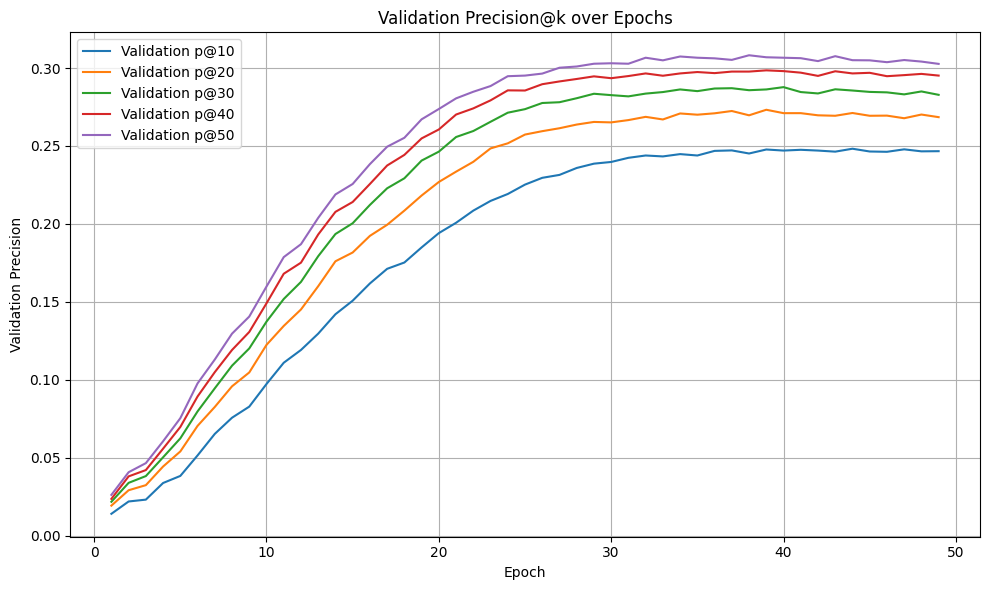

In [ ]:
os.makedirs("models", exist_ok=True)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters for training
num_epochs = 100
batch_size = 8
learning_rate = 1e-4

# Build MusicDataset using preloaded tracks_df
music_dataset = MusicDataset(tracks_df=tracks_df,
                              lyric_csv=lyric_csv_path,
                              mel_csv=mel_csv_path,
                              cooccur_model=w2v_model,
                              max_tags=max_tags,
                              desired_lyric_dim=desired_lyric_dim,
                              desired_mel_dim=desired_mel_dim)
track_features = build_track_features(music_dataset)
track_id_to_index = build_track_id_to_index(tracks_df)
num_tracks = len(track_id_to_index)

# Build SessionDataset
session_dataset = SessionDataset(sessions_csv=sessions_csv_path,
                                  track_features_dict=track_features,
                                  track_id_to_index=track_id_to_index,
                                  max_session_length=None,
                                  desired_lyric_dim=desired_lyric_dim,
                                  desired_mel_dim=desired_mel_dim)
total = len(session_dataset)
train_size = int(0.7 * total)
val_size = int(0.15 * total)
test_size = total - train_size - val_size
train_ds, val_ds, test_ds = random_split(session_dataset, [train_size, val_size, test_size])
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=session_collate_fn)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=session_collate_fn)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=session_collate_fn)

# Initialize model components
track_encoder = TrackEncoder(d_model=d_model, nhead=nhead, num_layers_mod=num_layers_mod,
                              num_layers_fusion=num_layers_fusion, tag_vocab_size=len(tag2idx)+1,
                              tag_embed_dim=tag_embed_dim, max_tags=max_tags, mel_dim=desired_mel_dim)
session_predictor = SessionPredictor(d_model=d_model, nhead=nhead,
                                      num_layers=session_transformer_layers, num_tracks=num_tracks)
model = SessionModel(track_encoder, session_predictor)
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss(ignore_index=-100)

early_stop_patience = 5
best_val_p_at_k = 0.0
epochs_no_improve = 0

train_losses = []
val_losses = []

k_values = [10, 20, 30, 40, 50]
val_p_at_k_dict = {k: [] for k in k_values}

# Train model
for epoch in range(num_epochs):
    train_loss = train_session_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_p_at_k = evaluate_session(model, val_loader, criterion, device, k=10)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    for k in k_values:
        _, p_at_k = evaluate_session(model, val_loader, criterion, device, k=k)
        val_p_at_k_dict[k].append(p_at_k)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val p@10: {val_p_at_k:.4f}")

    # Early stopping
    if val_p_at_k > best_val_p_at_k:
        best_val_p_at_k = val_p_at_k
        epochs_no_improve = 0
        torch.save(model.state_dict(), "models/best_session_model.pth")
        print("New best model saved with p@10: {:.4f}".format(best_val_p_at_k))
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= early_stop_patience:
            print("Early stopping triggered due to no improvement in p@10 for 5 epochs.")
            break

model.load_state_dict(torch.load("models/best_session_model.pth"))
model.eval()

# Evaluate on the test set
test_results = []
for k in k_values:
    test_loss, test_p = evaluate_session(model, test_loader, criterion, device, k=k)
    test_results.append({"k": k, "Test Loss": test_loss, "Precision": test_p})
    print(f"Test Loss: {test_loss:.4f} | Test p@{k}: {test_p:.4f}")

df_test_results = pd.DataFrame(test_results)
print("\nTest Set Evaluation:")
print(df_test_results)

actual_epochs = len(train_losses)
epochs_range = range(1, actual_epochs + 1)

plt.figure(figsize=(10, 6))
for k in k_values:
    plt.plot(epochs_range, val_p_at_k_dict[k], label=f'Validation p@{k}')
plt.xlabel("Epoch")
plt.ylabel("Validation Precision")
plt.title("Validation Precision@k over Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

---

<a name="4.7"></a>
## **4.7 Interpretation of Results**

### **Training Dynamics**

The model was trained for a maximum of 100 epochs, but early stopping was triggered at **epoch 49**, once validation Precision@10 ceased to improve for five consecutive epochs.

Throughout training:
- The **training loss decreased steadily**, indicating the model was effectively fitting the data.
- **Validation loss** fluctuated slightly but remained within a narrow range after epoch 20.
- **Precision@10** showed consistent improvement over the first 30 epochs, with smaller gains in later epochs, suggesting diminishing returns on additional training.
- By the end of training, the best validation Precision@10 reached **0.2482**.

This indicates that while the model starts with limited predictive ability, it quickly learns meaningful patterns within the session sequences and improves its ranking accuracy over time.

---

### **Test Set Performance**

After training, the best-performing model was evaluated on a held-out test set. The key metric, **Precision@K**, was computed for several values of K to assess how well the model ranks relevant tracks among its top predictions.

| **K** | **Test Precision@K** |
|------:|---------------------:|
| 10    | 0.3160              |
| 20    | 0.3513              |
| 30    | 0.3700              |
| 40    | 0.3836              |
| 50    | 0.3940              |

- At **K=10**, over **31.6%** of the time, the correct next track appeared within the model’s top 10 recommendations.
- Precision continues to improve at larger K, demonstrating that while the model may not always rank the correct track first, it often includes it in a shortlist of plausible candidates.

This performance level is notable, especially given the complexity of session prediction in a large item space. It suggests the model is learning to surface relevant options early in the ranked list, which aligns with how music recommendation systems are used in practice.

---

### **Observations**

- **Modal Fusion Strategy**: The use of modality-specific transformers followed by a fusion transformer appears effective. The improvement in Precision@10 over time reflects the model's ability to synthesize information across lyrics, audio, metadata, and co-occurrence.
  
- **Session-Level Modeling**: Incorporating a causal transformer with learnable positional encoding allows the model to leverage sequential context effectively. This is crucial for capturing the temporal dynamics of user sessions.

- **Model Robustness**: Early stopping helped prevent overfitting, and the consistent improvement in validation Precision@K indicates the model generalized well to unseen sequences.

---
---

<a name="ablation"></a>
# **5. Ablation Study**

This section performs an ablation study to evaluate the importance of each modality (lyrics, mel, metadata, co-occurrence) in next-track prediction.

The function evaluate_with_ablation replaces selected input modalities with random noise during evaluation, simulating the absence or corruption of that modality. Precision@k is then computed to assess how performance degrades under each configuration.

The experiment runs multiple evaluation configurations, each with different combinations of modalities kept or ablated, across several k values (e.g., Precision@10, @20, ..., @50). The results are collected into a DataFrame to compare how well the model performs when certain modalities are removed, providing insight into which features contribute most to recommendation quality.

In [ ]:
def evaluate_with_ablation(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader,
                             criterion: torch.nn.Module, device: torch.device,
                             ablate_modalities: list, k: int = 10) -> (float, float):
    """
    Evaluate the model with selected modalities ablated by replacing with random noise,
    computing precision@k.
    """
    model.eval()
    total_loss = 0.0
    total_valid = 0
    hit_count = 0

    with torch.no_grad():
        for batch in dataloader:
            lyrics = batch['lyrics'].to(device)
            mels = batch['mels'].to(device)
            meta_conts = batch['meta_conts'].to(device)
            tag_indices = batch['tag_indices'].to(device)
            cooccurs = batch['cooccurs'].to(device)

            # Ablate modalities not kept with random noise.
            if 'lyric' in ablate_modalities:
                lyrics = torch.randn_like(lyrics)
            if 'mel' in ablate_modalities:
                mels = torch.randn_like(mels)
            if 'metadata' in ablate_modalities:
                meta_conts = torch.randn_like(meta_conts)
                tag_indices = torch.randint(low=0, high=len(tag2idx)+1, size=tag_indices.shape, device=tag_indices.device)
            if 'cooccur' in ablate_modalities:
                cooccurs = torch.randn_like(cooccurs)

            logits = model(lyrics, mels, meta_conts, tag_indices, cooccurs)
            logits = logits.transpose(0, 1)

            targets = batch['targets'].to(device)
            loss = criterion(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
            total_loss += loss.item()

            for i in range(targets.size(0)):
                for j in range(targets.size(1)):
                    t = targets[i, j].item()
                    if t == -100:
                        continue
                    total_valid += 1
                    topk = torch.topk(logits[i, j], k).indices
                    if t in topk.cpu().tolist():
                        hit_count += 1

    p_at_k = hit_count / total_valid if total_valid > 0 else 0.0
    return total_loss / len(dataloader), p_at_k

all_modalities = {'lyric', 'mel', 'metadata', 'cooccur'}

# Define the evaluation configurations in terms of modalities to keep
ablation_configs_keep = [
    ("All", ['lyric', 'mel', 'metadata', 'cooccur']),
    ("Metadata", ['metadata']),
    ("Metadata + Lyrics", ['metadata', 'lyric']),
    ("Metadata + Mel", ['metadata', 'mel']),
    ("Metadata + Mel + Lyrics", ['metadata', 'mel', 'lyric']),
    ("Lyrics + Mel", ['lyric', 'mel'])
]

k_values = [10, 20, 30, 40, 50]

results = []
for config_name, keep_modalities in ablation_configs_keep:
    ablate_modalities = list(all_modalities - set(keep_modalities))
    row = {"Configuration": config_name}
    for k in k_values:
        loss, p_at_k = evaluate_with_ablation(model, test_loader, criterion, device,
                                                  ablate_modalities, k=k)
        row[f'Precision@{k}'] = p_at_k
    results.append(row)

df_performance = pd.DataFrame(results)
print(df_performance)


             Configuration  Precision@10  Precision@20  Precision@30  \
0                      All      0.316026      0.351262      0.370033   
1                 Metadata      0.082217      0.109221      0.133919   
2        Metadata + Lyrics      0.194731      0.238968      0.265752   
3           Metadata + Mel      0.220198      0.250494      0.273765   
4  Metadata + Mel + Lyrics      0.294182      0.327442      0.349067   
5             Lyrics + Mel      0.165862      0.191548      0.209660   

   Precision@40  Precision@50  
0      0.383644      0.393963  
1      0.150494      0.158617  
2      0.285510      0.292536  
3      0.287267      0.302086  
4      0.361910      0.373655  
5      0.228869      0.241603  


<a name="ablation-interpret"></a>
### 5.1 Interpretation of Ablation Study

Below, we decribes what the results of the ablation study tell us about our model and what limitations our model will face.
* **All:**
   * With all the embeddings used, we obtain a precision@10 of 0.316, aligning with our results in *section 4.8*
* **Metadata Only:**
  * With a precision@10 of 0.08, indicating that while the metadata alonge is not sufficient, it can contribute significantly to overall performance, confirming it is an important feature in our model.
* **Metadata + Lyrics:**
 * When the metadata is combined with the lyrics, the precision@10 shoots up to 0.19 (61% of the precision with all the embedding). This indicates the importance of the lyrics embeddings to our model. Without lyrics, we would lose a lot of precision.
 * This also highlights one of the limitation of our model. Since the lyrical embedding contributes so much to our performance, non-lyrical songs/ users who listens to non-lyrical songs, will receive much less precised recommendations.
 * Additionlly, listeners who tends to listen to non english songs, would likely be affected due to teh lyric embedding failinf to capture the meaning of these songs.
* **Metadata + Mel-Spectograms:**
  * With a precision@10 of 0.22 (70% of the precision with all embeddings combine), we can confidently say that the mel-spectogram embedding also has a signigicant importance in our model.
  * Despite our pca from *section 3.1* not having the best results, this ablation study shows that it was still good enough to provide meaningful values to the model and contribute significantly to prediciting next songs.
  * Considering the importance of the mel-spectograms, and the depreciation of the spotify API, this indicates that for newer data, we must find a different method to obtain song previews.
* **Lyrics + Mel:**
  * The two previous ablation showed a combination with the metadata, so we look at what the lyrics and mel when they are combined together without the metadata.
  * With a precision@10 0f 0.16, this shows that without the metadata, we actually lose a lot of precion. The lyrics and mel-spectogram alone are not enough, the metadata is essential to produce a good enough prediction.
  * From this, we can say that newer songs that do not have 'tags' yet, or whose track does not exist in last.fm, would suffer quite a lot, since we are losing metadata information which has a significant contribution to our model's ability to predict.
* **Metadata + Mel + Lyrics:**
 * Lastly, we look at all embeddings without the co-occurence data. This tells the importance of the co-occurence embedding to our model
 * With a precision@10 of 0.29 (93% of the precision with all embeddings), this indicates that the co-occurence data does not contribute that much to our model predictions
 * This signifies that newer songs (which we cannot get co-occurence data for) won't be significantly impacted by the lack of co-occurence data


### **Model Performance on Unseen Data (Test Set + New Songs):** https://drive.google.com/file/d/1ad5xJUDuc9b8G_Z2UR7UCJXTEUzAongH/view?usp=sharing

We created a front end for the demostration and this also where we tested new data. Above is a link to the demostration video which shows perfornance on new unseen data.

----
---

<a name="conclusion"></a>
# **6. Conclusion**

This section summarizes the higher-level findings from the report/project. We highlight and discuss challenges, limitations and insights gathered from the execution and success of the project.

---
<a name="challenges-insights"></a>
## **6.1 Challenges & Insights**

1. **Limited Song Previews**  
   - Due to changes in Spotify’s policies and deprecation of certain APIs, audio previews are only available for tracks released before 2023.  
   - We had to rely heavily on Last.fm for track data, which can be less detailed and restricted to that platform’s user base.  
   - To work around missing preview data, we also used **Kaggle** as a backup source for older tracks and missing audio previews.

2. **Strict API Rate Limits**  
   - Pulling lyrics from the Genius API required careful management of request rates to avoid hitting rate limits. We implemented request delays and batch processing to stay within allowed quotas.

3. **Model Architecture Experimentation**  
   - We initially tried an **autoencoder** for audio embeddings and an **RNN** (LSTM layers) for the session predictor, but these approaches fell short of our performance goals. For instance, the RNN achieved a validation precision@10 of just 0.0052 over 10 epochs, significantly lower than the ~0.3 precision@k often targeted in similar recommendation systems from the literature review. The autoencoder, on the other hand, was barely able to distinguish between different genres in the PCA. We then tried CNN variations, which did much better at the PCA but still not good enough, until we added the GRU layer.

   - Adopting a **GRU** (Gated Recurrent Unit) layer with a pretrained ResNet50 and **transformer** components proved more effective for sequential data, especially when dealing with mel-spectrogram inputs.

4. **Pretrained Models Outperformed Custom Architectures**  
   - We tested multiple custom models but found that **pretrained** options (like **Sentence-BERT** for lyrics) consistently produced better results.  
   - This underscores the value of leveraging **off-the-shelf** pretrained embeddings, especially when data diversity is limited.

5. **Ablation Studies for Multiple Inputs**  
   - Our pipeline includes various embeddings (lyrics, audio, co-occurrence, etc.). Conducting **ablation studies** (systematically removing one modality at a time) helped reveal how each input contributed to the overall model performance.

By addressing these challenges, we refined our system to better handle multi-modal music recommendations.

---
<a name="limitations"></a>
## **6.2 Model Limitations**


1. **New Songs Cannot Be Recommended**  
   New tracks introduced to the model are restricted to inputs only and do not appear in the recommendation set (as shown in our demo). This gap occurs because new songs haven’t yet been integrated into the model’s training pipeline.

2. **Bias from Limited Diversity**  
   Our dataset is predominantly composed of English, lyrical songs. This narrow scope raises concerns about cultural and linguistic bias, potentially disadvantaging users with different language or music preferences.

3. **Lack of Co-occurrence Data**  
   One of our core embeddings relies on co-occurrence patterns (tracks appearing together in user sessions). Since new songs have no usage history, they lack co-occurrence data, limiting the model’s ability to accurately represent these tracks in recommendations.

These points underscore several **areas for future improvement**, such as expanding the dataset’s diversity, refining how new tracks are incorporated, and mitigating biases in the recommendation pipeline.

---
<a name="next-steps"></a>
## **6.3 Next Steps**

1. **Improve Cold-Start Handling for New Songs**  
   Currently, new tracks lack co-occurrence data, limiting their ability to be recommended. A key next step is to develop a fallback mechanism that leverages only audio and lyric embeddings when session data is unavailable.

2. **Enhance Fusion Strategy**  
   Explore more advanced fusion methods, such as attention-based mechanisms, to better weigh and combine modality-specific embeddings (lyrics, audio, metadata, and co-occurrence) based on the context of each session.

3. **Expand Dataset Diversity to Reduce Bias**  
   Broaden the dataset to include more non-English songs, instrumental tracks, and diverse genres to reduce bias and improve fairness in recommendations. This will help the model generalize better to different users and listening preferences.

In [ ]:
%%shell
jupyter nbconvert --to html /content/mie1517_final_report_team12.ipynb

[NbConvertApp] Converting notebook /content/mie1517_final_report_team12.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 1342767 bytes to /content/mie1517_final_report_team12.html


## All imports